### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

### A note for students using this template
This Jupyter Notebook is a template you can use to complete the Course 2 assignment: Diagnostic Analysis using Python. 

Keep in mind: 
- You are **not required** to use this template to complete the assignment. 
- If you decide to use this template for your assignment, make a copy of the notebook and save it using the assignment naming convention: **LastName_FirstName_DA201_Assignment_Notebook.ipynb**.
- The workflow suggested in this template follows the Assignment Activities throughout the course.
- Refer to the guidance on the Assignment Activity pages for specific details. 
- The markup and comments in this template identify the key elements you need to complete before submitting the assignment.
- Make this notebook your own by adding your process notes and rationale using markdown, add links, screenshots, or images to support your analysis, refine or clarify the comments, and change the workflow to suit your process.
- All elements should be functional and visible in your Notebook. 
- After completing each Assignment Activity, back up your work to a safe location. This would allow you to revert to a previous state in the case of making a mistake in the code, or deleting a section by mistake. (A simple way of doing this is to save or mail a compressed version at frequent intervals).

 > ***Markdown*** Remember to change cell types to `Markdown`. You can review [Markdown basics](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax) to find out how to add formatted text, links, and images to your notebook.

# 

# Assignment activity 1

### Plan your approach

It seems I need to break down the data into subsets of the data so that the analysis can happen. If I take a look at how each area (ICB and sub-ICB) have faired in regards to appointments, I may be able to see a pattern across geographies.

I'm interesting in seeing if there is any relationship between DNA and other factors such as geography or time between booking and appointment.

# Assignment activity 2

### Prepare your workstation

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
print(ad.shape)
print(ad.columns)
print(ad.dtypes)
ad.head()

(137793, 8)
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')
sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [3]:
# Determine whether there are any missing values
ad.isna().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

None of the cells in the dataset are empty.

In [4]:
# Determine the metadata of the data set.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [5]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [6]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
print(ar.shape)
print(ar.columns)
print(ar.dtypes)
ar.head()

(596821, 7)
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [7]:
# Determine whether there are missing values.
ar.isna().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [8]:
# Determine the metadata of the data set.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [9]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [10]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

# View the DataFrame.
print(nc.shape)
print(nc.columns)
print(nc.dtypes)
nc.head()

(817394, 8)
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')
appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [11]:
# Determine whether there are missing values.
nc.isna().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [12]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [13]:
# Determine the descriptive statistics of the data set.
nc.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


### Explore the data set

**Question 1:** How many locations are there in the data set?

In [14]:
# Determine the number of locations.
print(nc['sub_icb_location_name'].value_counts().count())
print(ad['sub_icb_location_ons_code'].value_counts().count())
print("There are",
      nc['sub_icb_location_name'].value_counts().count(),
      "different sub-icb locations.")

106
106
There are 106 different sub-icb locations.


In [15]:
# Determine the number of wider locations.
print(nc['icb_ons_code'].value_counts().count())
print(f"""There are {nc['icb_ons_code'].value_counts().count()} wider locations, however we do not have their names, only their ONS location codes.""")

42
There are 42 wider locations, however we do not have their names, only their ONS location codes.


**Question 2:** What are the five locations with the highest number of appointments?



In [16]:
# Determine the top five locations based on record count.
nc_record_count = nc['sub_icb_location_name'].value_counts()


print(f"""The top 5 locations based on record count:
      {nc_record_count.head(5).to_string(header=False)}""")

The top 5 locations based on record count:
      NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837


All of these are in the south of England. These figures don't necessarily suggest most appointments, but rather most times they occur in the dataset.

**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [17]:
# Determine the number of service settings.
print(nc['service_setting'].value_counts())
print(f"""There are {nc['service_setting'].value_counts().count()} different service settings.""")

service_setting
General Practice             359274
Primary Care Network         183790
Other                        138789
Extended Access Provision    108122
Unmapped                      27419
Name: count, dtype: int64
There are 5 different service settings.


In [18]:
# Determine the number of context types.
print(nc['context_type'].value_counts())
print(f"""There are {nc['context_type'].value_counts().count()} different context types.""")

context_type
Care Related Encounter    700481
Inconsistent Mapping       89494
Unmapped                   27419
Name: count, dtype: int64
There are 3 different context types.


In [19]:
# Determine the number of national categories.

print(nc['national_category'].value_counts())
print(f"""There are {nc['national_category'].value_counts().count()} different national categories.""")

national_category
Inconsistent Mapping                                                   89494
General Consultation Routine                                           89329
General Consultation Acute                                             84874
Planned Clinics                                                        76429
Clinical Triage                                                        74539
Planned Clinical Procedure                                             59631
Structured Medication Review                                           44467
Service provided by organisation external to the practice              43095
Home Visit                                                             41850
Unplanned Clinical Activity                                            40415
Patient contact during Care Home Round                                 28795
Unmapped                                                               27419
Care Home Visit                                           

There is a lot of inconsistent mapping. 

In [20]:
# Determine the number of appointment statuses.
print(ar['appointment_status'].value_counts())
print(f"""There are {ar['appointment_status'].value_counts().count()} different appointment statuses.""")

appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64
There are 3 different appointment statuses.


There are a lot of inconsistent mapping in the national category. This immediately says to me that the data is not collected in a successful way. Creating a data dictionary across the whole of the NHS across the whole of the country (England) would be beneficial for future analyses.
It seems as though there were no available appointments during the time period. All the appointments were booked up, however it is not clear as to the ratio of attended to not attended due to the unknown value in the data which represents an error in the reporting after the appointment has been booked.

# Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [21]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head(5)

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

There dates in the ad DataFrame are objects, not in datetime format.

In [22]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc['appointment_date'].head(5)

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

The dates in the nc DataFrame are in datetime format.

In [23]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
ad['appointment_date'].head()

0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns]

The format has changed to a datetime format now.

In [24]:
# View the ar DataFrame
print(ar.dtypes)
ar.head()

icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [25]:
# Change the date format or ar['appointment_date']

# There isn't an appointment_date field in ar.
# Adding one instead using the appointment_month data.
# This will result in every value in the new appointment_date column beginning on the first of the month.
ar['appointment_date'] = pd.to_datetime(ar['appointment_month'])

# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2020-01-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2020-01-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2020-01-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2020-01-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2020-01-01


In [26]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
print(nc['appointment_date'].max().date())
print(nc['appointment_date'].min().date())
print(f"""The National Category data set starts at {nc['appointment_date'].min().date()}, and ends at {nc['appointment_date'].max().date()}.""")

2022-06-30
2021-08-01
The National Category data set starts at 2021-08-01, and ends at 2022-06-30.


In [27]:
# Check the date for ad DataFrame.
print(ad['appointment_date'].max().date())
print(ad['appointment_date'].min().date())
print(f"""The Actual Duration data set starts at {ad['appointment_date'].min().date()},\
 and ends at {ad['appointment_date'].max().date()}.""")

2022-06-30
2021-12-01
The Actual Duration data set starts at 2021-12-01, and ends at 2022-06-30.


In [28]:
# Chec the dates for the ar DataFrame.
print(ar['appointment_date'].max().date())
print(ar['appointment_date'].min().date())
print(f"""The Appointments Regional data set starts at\
 {ar['appointment_date'].min().date()},\
 and ends at\
 {ar['appointment_date'].max().date()}.\
 It should be acknowledged that these dates are not true representations of the information.""")

2022-06-01
2020-01-01
The Appointments Regional data set starts at 2020-01-01, and ends at 2022-06-01. It should be acknowledged that these dates are not true representations of the information.


The information across all three data sets starts at the beginning of 2020 (1st January 2020),and ends at the end of June 2022 (30th June 2022). There is some crossover between the data, but the Appointments Regional data set starts the earliest, but they all finish in the same month. 

**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [29]:
# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [30]:
# Create a subset of the nc DataFrame focusing on North West London - W2U3Z.
nc_NorthWestLondon = nc[nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z']

# View the subsetted DataFrame.
nc_NorthWestLondon

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
794321,2021-08-01,E54000027,NHS North West London ICB - W2U3Z,Unmapped,Unmapped,Unmapped,607,2021-08
794322,2021-08-01,E54000027,NHS North West London ICB - W2U3Z,Other,Inconsistent Mapping,Inconsistent Mapping,6,2021-08
794323,2021-08-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Inconsistent Mapping,Inconsistent Mapping,47,2021-08
794324,2021-08-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Walk-in,74,2021-08
794325,2021-08-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Planned Clinics,98,2021-08
...,...,...,...,...,...,...,...,...
807323,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,6,2022-06
807324,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Routine,25,2022-06
807325,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Acute,217,2022-06
807326,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Clinical Triage,103,2022-06


In [31]:
# Filter the dates of the appointments.
nc_NorthWestLondon = nc_NorthWestLondon[
    (nc_NorthWestLondon['appointment_date'] >= '2022-01-01')
    &
    (nc_NorthWestLondon['appointment_date'] <= '2022-06-01')]

# Sense check the filtered DataFrame.
print(nc_NorthWestLondon.shape)
nc_NorthWestLondon

(5936, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
800289,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Unmapped,Unmapped,Unmapped,496,2022-01
800290,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Clinical Triage,19,2022-01
800291,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Other,Inconsistent Mapping,Inconsistent Mapping,1,2022-01
800292,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Inconsistent Mapping,Inconsistent Mapping,16,2022-01
800293,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Planned Clinics,29,2022-01
...,...,...,...,...,...,...,...,...
806220,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Home Visit,4,2022-06
806221,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Routine,27,2022-06
806222,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Unplanned Clinical Activity,626,2022-06
806223,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Acute,224,2022-06


In [32]:
# Determine the number of service settings in the North West London ICB between the dates.
nc_NorthWestLondon['service_setting'].value_counts()

service_setting
General Practice             2104
Other                        1318
Primary Care Network         1272
Extended Access Provision    1090
Unmapped                      152
Name: count, dtype: int64

General practice had the most reported service settings in North West London ICB.

In [33]:
# Which service setting reported the most appointments in Kent and Medway.
# Create a subset of the NC data set for NHS Kent and Medway ICB - 91Q.
nc_KentMedway = nc[nc['sub_icb_location_name'] == 'NHS Kent and Medway ICB - 91Q']

# View the subset
nc_KentMedway 

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
637416,2021-08-01,E54000032,NHS Kent and Medway ICB - 91Q,Primary Care Network,Care Related Encounter,General Consultation Routine,6,2021-08
637417,2021-08-01,E54000032,NHS Kent and Medway ICB - 91Q,Primary Care Network,Care Related Encounter,General Consultation Acute,3,2021-08
637418,2021-08-01,E54000032,NHS Kent and Medway ICB - 91Q,Other,Inconsistent Mapping,Inconsistent Mapping,30,2021-08
637419,2021-08-01,E54000032,NHS Kent and Medway ICB - 91Q,Other,Care Related Encounter,Planned Clinics,4,2021-08
637420,2021-08-01,E54000032,NHS Kent and Medway ICB - 91Q,Other,Care Related Encounter,General Consultation Acute,42,2021-08
...,...,...,...,...,...,...,...,...
650048,2022-06-30,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,9,2022-06
650049,2022-06-30,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,General Consultation Routine,101,2022-06
650050,2022-06-30,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,General Consultation Acute,31,2022-06
650051,2022-06-30,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,Clinical Triage,52,2022-06


In [34]:
# Filter the Kent and Medway subset further by date.
nc_KentMedway = nc_KentMedway[
    (nc_KentMedway['appointment_date'] >= '2022-01-01')
    &
    (nc_KentMedway['appointment_date'] <= '2022-06-01')]

# Sense check the filtered subset.
print(nc_KentMedway.shape)
nc_KentMedway

(5758, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
643245,2022-01-01,E54000032,NHS Kent and Medway ICB - 91Q,Other,Care Related Encounter,General Consultation Routine,3,2022-01
643246,2022-01-01,E54000032,NHS Kent and Medway ICB - 91Q,Unmapped,Unmapped,Unmapped,6,2022-01
643247,2022-01-01,E54000032,NHS Kent and Medway ICB - 91Q,Primary Care Network,Care Related Encounter,General Consultation Routine,9,2022-01
643248,2022-01-01,E54000032,NHS Kent and Medway ICB - 91Q,Primary Care Network,Care Related Encounter,Structured Medication Review,4,2022-01
643249,2022-01-01,E54000032,NHS Kent and Medway ICB - 91Q,Primary Care Network,Care Related Encounter,General Consultation Acute,21,2022-01
...,...,...,...,...,...,...,...,...
648998,2022-06-01,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,Planned Clinics,3,2022-06
648999,2022-06-01,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,6,2022-06
649000,2022-06-01,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,General Consultation Routine,87,2022-06
649001,2022-06-01,E54000032,NHS Kent and Medway ICB - 91Q,Extended Access Provision,Care Related Encounter,General Consultation Acute,32,2022-06


In [35]:
# Determine the number of service settings for Kent and Medway.
nc_KentMedway['service_setting'].value_counts()

service_setting
General Practice             1939
Primary Care Network         1400
Other                        1277
Extended Access Provision     995
Unmapped                      147
Name: count, dtype: int64

General practice had the most reported service settings in Kent and Medway ICB.

In [36]:
# Which service setting reported the most appointments in Devon.
# Create a subset of the nc data set for NHS Devon ICB - 15N.
nc_Devon = nc[nc['sub_icb_location_name'] == 'NHS Devon ICB - 15N']

# View the DataFrame.
nc_Devon

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
503214,2021-08-01,E54000037,NHS Devon ICB - 15N,Unmapped,Unmapped,Unmapped,20,2021-08
503215,2021-08-01,E54000037,NHS Devon ICB - 15N,General Practice,Care Related Encounter,Planned Clinics,7,2021-08
503216,2021-08-01,E54000037,NHS Devon ICB - 15N,General Practice,Care Related Encounter,General Consultation Routine,95,2021-08
503217,2021-08-01,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2021-08
503218,2021-08-01,E54000037,NHS Devon ICB - 15N,General Practice,Care Related Encounter,Planned Clinical Procedure,20,2021-08
...,...,...,...,...,...,...,...,...
515735,2022-06-30,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,Planned Clinics,40,2022-06
515736,2022-06-30,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,32,2022-06
515737,2022-06-30,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,General Consultation Routine,47,2022-06
515738,2022-06-30,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,General Consultation Acute,16,2022-06


In [37]:
# Filter the devon subset by date.
nc_Devon = nc_Devon[
    (nc_Devon['appointment_date'] >= '2022-01-01')
    &
    (nc_Devon['appointment_date'] <= '2022-06-01')]

# Sense check the filtered subset DataFrame.
print(nc_Devon.shape)
nc_Devon

(5785, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
508880,2022-01-01,E54000037,NHS Devon ICB - 15N,Unmapped,Unmapped,Unmapped,10,2022-01
508881,2022-01-01,E54000037,NHS Devon ICB - 15N,Primary Care Network,Care Related Encounter,Planned Clinics,19,2022-01
508882,2022-01-01,E54000037,NHS Devon ICB - 15N,Primary Care Network,Care Related Encounter,General Consultation Routine,11,2022-01
508883,2022-01-01,E54000037,NHS Devon ICB - 15N,Other,Inconsistent Mapping,Inconsistent Mapping,1,2022-01
508884,2022-01-01,E54000037,NHS Devon ICB - 15N,General Practice,Care Related Encounter,Planned Clinics,2,2022-01
...,...,...,...,...,...,...,...,...
514660,2022-06-01,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,Planned Clinics,18,2022-06
514661,2022-06-01,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,27,2022-06
514662,2022-06-01,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,General Consultation Routine,41,2022-06
514663,2022-06-01,E54000037,NHS Devon ICB - 15N,Extended Access Provision,Care Related Encounter,General Consultation Acute,13,2022-06


In [38]:
# Determine the number of service settings for Devon.
nc_Devon['service_setting'].value_counts()

service_setting
General Practice             1924
Primary Care Network         1451
Other                        1183
Extended Access Provision    1076
Unmapped                      151
Name: count, dtype: int64

General Practice had the most reported service settings in Devon.

In [39]:
# Which service setting reported the most appointments in Hampshire and Isle Of Wight.
# Create a subset of the nc dataset for Hampshire and Isle of Wight
nc_HampIoW = nc[nc['sub_icb_location_name'] == 'NHS Hampshire and Isle Of Wight ICB - D9Y0V']

# View the DataFrame.
nc_HampIoW

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
764599,2021-08-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,General Practice,Inconsistent Mapping,Inconsistent Mapping,2,2021-08
764600,2021-08-02,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Unmapped,Unmapped,Unmapped,2424,2021-08
764601,2021-08-02,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Primary Care Network,Care Related Encounter,Unplanned Clinical Activity,21,2021-08
764602,2021-08-02,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Primary Care Network,Care Related Encounter,Structured Medication Review,3,2021-08
764603,2021-08-02,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Primary Care Network,Care Related Encounter,Social Prescribing Service,54,2021-08
...,...,...,...,...,...,...,...,...
776765,2022-06-30,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,45,2022-06
776766,2022-06-30,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,Home Visit,2,2022-06
776767,2022-06-30,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,General Consultation Routine,34,2022-06
776768,2022-06-30,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,General Consultation Acute,32,2022-06


In [40]:
# Filter the Hampshire and Isle of Wight subset by date.
nc_HampIoW = nc_HampIoW[
    (nc_HampIoW['appointment_date'] >= '2022-01-01')
    &
    (nc_HampIoW['appointment_date'] <= '2022-06-01')]

# Sense check the DataFrame.
print(nc_HampIoW.shape)
nc_HampIoW

(5528, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
770215,2022-01-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,General Practice,Inconsistent Mapping,Inconsistent Mapping,4,2022-01
770216,2022-01-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,General Practice,Care Related Encounter,General Consultation Routine,398,2022-01
770217,2022-01-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,General Practice,Care Related Encounter,Planned Clinical Procedure,69,2022-01
770218,2022-01-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,General Practice,Care Related Encounter,Clinical Triage,1,2022-01
770219,2022-01-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Unmapped,Unmapped,Unmapped,19,2022-01
...,...,...,...,...,...,...,...,...
775738,2022-06-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,44,2022-06
775739,2022-06-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,Home Visit,5,2022-06
775740,2022-06-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,General Consultation Routine,30,2022-06
775741,2022-06-01,E54000042,NHS Hampshire and Isle Of Wight ICB - D9Y0V,Extended Access Provision,Care Related Encounter,General Consultation Acute,17,2022-06


In [41]:
# Determine the number of service settings.
nc_HampIoW['service_setting'].value_counts()

service_setting
General Practice             1863
Primary Care Network         1424
Other                        1076
Extended Access Provision    1038
Unmapped                      127
Name: count, dtype: int64

General Practice had the most reported service settings in Hampshire and Isle of Wight.

In [42]:
# Which service setting reported the most appointments in North East London.
# Create a subset of the nc data set for North East London.
nc_NorthEastLondon = nc[nc['sub_icb_location_name'] == 'NHS North East London ICB - A3A8R']

# View the subset DataFrame.
nc_NorthEastLondon

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
722247,2021-08-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,Unplanned Clinical Activity,1,2021-08
722248,2021-08-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,General Consultation Acute,11,2021-08
722249,2021-08-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Clinical Triage,16,2021-08
722250,2021-08-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,Clinical Triage,153,2021-08
722251,2021-08-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,11,2021-08
...,...,...,...,...,...,...,...,...
734079,2022-06-30,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,15,2022-06
734080,2022-06-30,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Home Visit,4,2022-06
734081,2022-06-30,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,General Consultation Routine,37,2022-06
734082,2022-06-30,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,General Consultation Acute,104,2022-06


In [43]:
# Filter the subset DataFrame for specific months.
nc_NorthEastLondon = nc_NorthEastLondon[
    (nc_NorthEastLondon['appointment_date'] >= '2022-01-01')
    &
    (nc_NorthEastLondon['appointment_date'] <= '2022-06-01')]

# Sense check the filtered subset.
print(nc_NorthEastLondon.shape)
nc_NorthEastLondon

(5456, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
727616,2022-01-01,E54000029,NHS North East London ICB - A3A8R,Other,Inconsistent Mapping,Inconsistent Mapping,44,2022-01
727617,2022-01-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Inconsistent Mapping,Inconsistent Mapping,2,2022-01
727618,2022-01-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,Unplanned Clinical Activity,2,2022-01
727619,2022-01-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,Structured Medication Review,2,2022-01
727620,2022-01-01,E54000029,NHS North East London ICB - A3A8R,General Practice,Care Related Encounter,Planned Clinics,3,2022-01
...,...,...,...,...,...,...,...,...
733067,2022-06-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Planned Clinics,25,2022-06
733068,2022-06-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,Home Visit,2,2022-06
733069,2022-06-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,General Consultation Routine,83,2022-06
733070,2022-06-01,E54000029,NHS North East London ICB - A3A8R,Extended Access Provision,Care Related Encounter,General Consultation Acute,111,2022-06


In [44]:
# Determine the number of service settings.
nc_NorthEastLondon['service_setting'].value_counts()

service_setting
General Practice             2137
Primary Care Network         1241
Other                        1008
Extended Access Provision     956
Unmapped                      114
Name: count, dtype: int64

General Practice has the most reported service settings for North East London.

In [45]:
# Check the service setting values between the top five sub-ICB locations.
print("For North West London:")
print(nc_NorthWestLondon['service_setting'].value_counts())
print(" ")
print("For Kent and Medway:")
print(nc_KentMedway['service_setting'].value_counts())
print(" ")
print("For Devon:")
print(nc_Devon['service_setting'].value_counts())
print(" ")
print("For Hampshire and Isle of Wight:")
print(nc_HampIoW['service_setting'].value_counts())
print(" ")
print("For North East London:")
print(nc_NorthEastLondon['service_setting'].value_counts())

For North West London:
service_setting
General Practice             2104
Other                        1318
Primary Care Network         1272
Extended Access Provision    1090
Unmapped                      152
Name: count, dtype: int64
 
For Kent and Medway:
service_setting
General Practice             1939
Primary Care Network         1400
Other                        1277
Extended Access Provision     995
Unmapped                      147
Name: count, dtype: int64
 
For Devon:
service_setting
General Practice             1924
Primary Care Network         1451
Other                        1183
Extended Access Provision    1076
Unmapped                      151
Name: count, dtype: int64
 
For Hampshire and Isle of Wight:
service_setting
General Practice             1863
Primary Care Network         1424
Other                        1076
Extended Access Provision    1038
Unmapped                      127
Name: count, dtype: int64
 
For North East London:
service_setting
General Practice 

All of the top 5 sub-ICB locations follow a similar distribution of service settings responses in the data.
London North East has the widest gap betwen General Practice and Primary Care Network.

**Question 3:** Which month had the highest number of appointments?

In [46]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.


In [47]:
# View the nc DataFrame and check appointment_date data type.
print(nc['appointment_date'].dtypes)
nc.head()


datetime64[ns]


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [48]:
# Determine the total number of appointments per month grouped by year and month.
nc['count_of_appointments'].groupby([
    nc['appointment_date'].dt.year,
    nc['appointment_date'].dt.month]
).sum().sort_values(ascending=False)

appointment_date  appointment_date
2021              11                  30405070
                  10                  30303834
2022              3                   29595038
2021              9                   28522501
2022              5                   27495508
                  6                   25828078
                  1                   25635474
                  2                   25355260
2021              12                  25140776
2022              4                   23913060
2021              8                   23852171
Name: count_of_appointments, dtype: int64

November 2021 was the busiest month. This is typical because the NHS is used more in the winter months. It is interesting that it was less busy in December 2021 and in January and February of 2022.

In [49]:
# View the ad data set and check the date type of the appointment date column.
print(ad['appointment_date'].dtype)
ad.head()

datetime64[ns]


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730


In [50]:
# Determine the total number of appointments per month grouped by year and month.
ad['count_of_appointments'].groupby([
    ad['appointment_date'].dt.year,
    ad['appointment_date'].dt.month]
).sum().sort_values(ascending=False)

appointment_date  appointment_date
2022              3                   27170002
                  5                   25343941
                  6                   23715317
                  1                   23597196
                  2                   23351939
2021              12                  22853483
2022              4                   21948814
Name: count_of_appointments, dtype: int64

The busiest month was March 2022 and the least busiest month was April 2022.

In [51]:
# View the ar data set and check the date type of the appointment date column.
print(ar['appointment_date'].dtype)
ar.head()

datetime64[ns]


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2020-01-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2020-01-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2020-01-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2020-01-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2020-01-01


In [52]:
# Determine the total number of appointments per month grouped by year and month.
ar['count_of_appointments'].groupby([
    ar['appointment_date'].dt.year,
    ar['appointment_date'].dt.month]
).sum().sort_values(ascending=False)

appointment_date  appointment_date
2021              11                  30405070
                  10                  30303834
2022              3                   29595038
2021              9                   28522501
2020              10                  28301932
2022              5                   27495508
2021              3                   27225424
2020              1                   27199296
2021              6                   26784182
2020              9                   26714255
2022              6                   25828078
2021              7                   25739219
2022              1                   25635474
                  2                   25355260
2021              12                  25140776
2020              11                  25061602
                  2                   24104621
                  3                   24053468
2022              4                   23913060
2021              4                   23879932
                  8      

There are fewer records during the height of the pandemic - this is because people were in lockdown and putting off seeing the GP. The most records were in November 2021 when England was not in Covid lockdown but during the winter squeeze.


**Question 4:** What was the total number of records per month?

In [53]:
# Total number of records per month for the ar data set.
ar.groupby([
    ar['appointment_date'].dt.year,
    ar['appointment_date'].dt.month])\
    .size()


appointment_date  appointment_date
2020              1                   20889
                  2                   20689
                  3                   21350
                  4                   19124
                  5                   18338
                  6                   18844
                  7                   19502
                  8                   19247
                  9                   20043
                  10                  20122
                  11                  19675
                  12                  19394
2021              1                   19319
                  2                   18949
                  3                   19369
                  4                   19452
                  5                   19384
                  6                   19814
                  7                   19899
                  8                   19786
                  9                   20441
                  10                  205

Just by looking at the figures in the thousands columns of the counted data, you can see that there is a slight osciliation between summer and winter but also taking in to account Covid lockdowns.

In [54]:
# Total number of records per month for the ad data set.
ad.groupby([
    ad['appointment_date'].dt.year,
    ad['appointment_date'].dt.month])\
    .size()


appointment_date  appointment_date
2021              12                  19507
2022              1                   19643
                  2                   18974
                  3                   21236
                  4                   19078
                  5                   20128
                  6                   19227
dtype: int64

This shows that this is actually quite a short time period for the actual duration data set. This shows a limititation in the recording of the data.

In [55]:
# Total number of records per month for the nc data set.
nc.groupby([
    nc['appointment_date'].dt.year,
    nc['appointment_date'].dt.month])\
    .size()


appointment_date  appointment_date
2021              8                   69999
                  9                   74922
                  10                  74078
                  11                  77652
                  12                  72651
2022              1                   71896
                  2                   71769
                  3                   82822
                  4                   70012
                  5                   77425
                  6                   74168
dtype: int64

This shows an increase in reporting since it started.

It will be interesting to see the counts of appointments compared to the locations to get an understanding of the variation over time

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [56]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [57]:
# View the data type of appointment month in the nc data set.
nc['appointment_month'].dtype

dtype('O')

It is an object, so needs to change 

In [58]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype('string')

# Check to see if successful.
nc['appointment_month'].dtype

string[python]

In [59]:
# Aggregate on monthly level and determine the sum of records per month.
nc_ss = nc.groupby(['appointment_month', 'service_setting'])\
['count_of_appointments'].sum().reset_index()


# View output.
nc_ss.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


**Service settings:**

<function matplotlib.pyplot.show(close=None, block=None)>

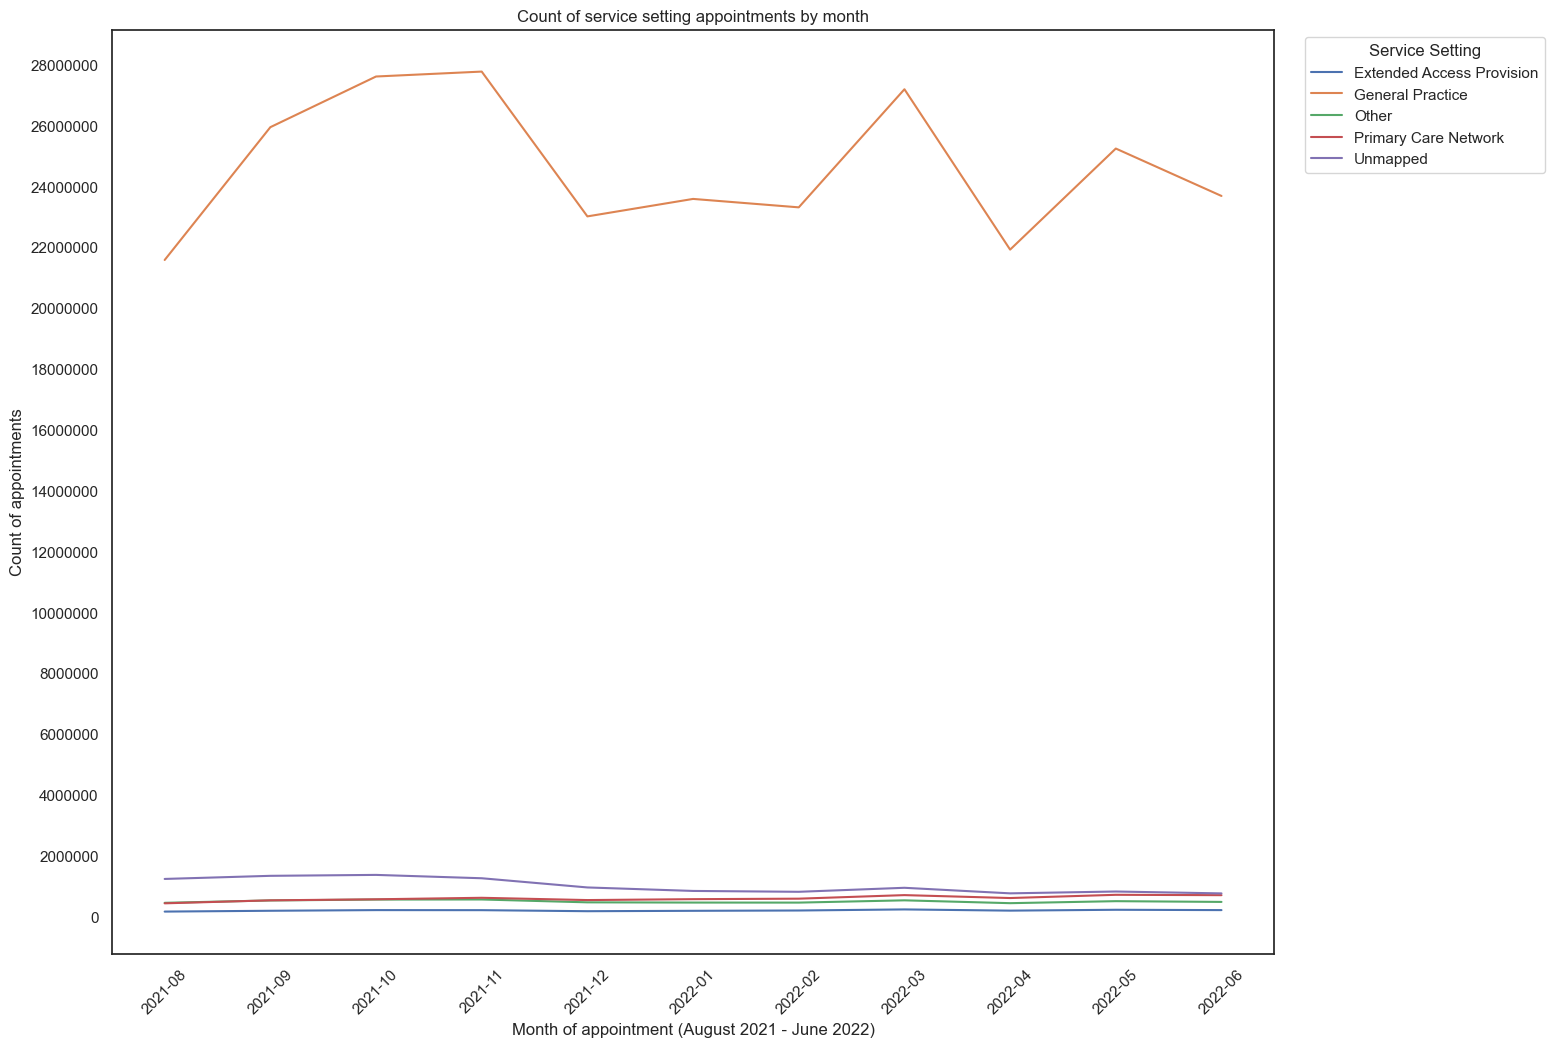

In [60]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
ax = sns.lineplot(data=nc_ss,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting')

# Format the plot.
ax.set_title('Count of service setting appointments by month')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Month of appointment (August 2021 - June 2022)')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('Service counts by month.png')
plt.show

**Context types:**

In [61]:
# Create a separate data set that can be used in future weeks. 
nc_ct = nc.groupby(['appointment_month', 'context_type'])\
['count_of_appointments'].sum().reset_index()

# View output.
nc_ct.head()

,appointment_month,context_type,count_of_appointments
0,2021-08,Care Related Encounter,20255235
1,2021-08,Inconsistent Mapping,2363093
2,2021-08,Unmapped,1233843
3,2021-09,Care Related Encounter,24404251
4,2021-09,Inconsistent Mapping,2782135


<function matplotlib.pyplot.show(close=None, block=None)>

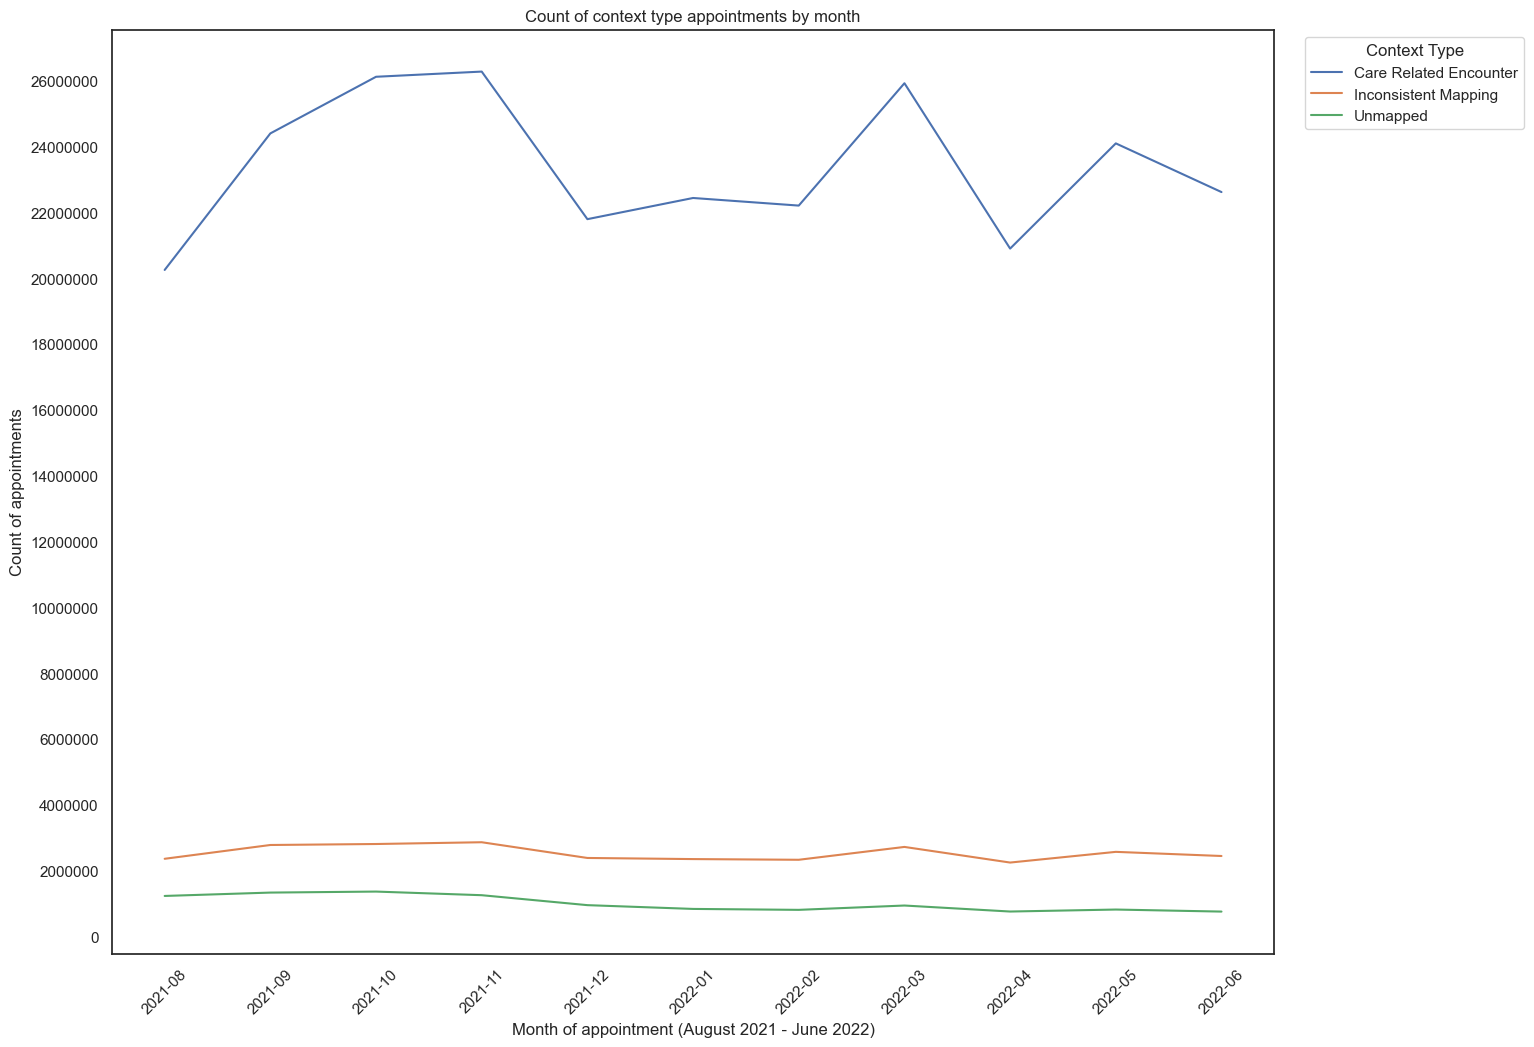

In [62]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
ax = sns.lineplot(data=nc_ct,
             x='appointment_month',
             y='count_of_appointments',
             hue='context_type')

# Format the plot.
ax.set_title('Count of context type appointments by month')
ax.legend(title='Context Type',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Month of appointment (August 2021 - June 2022)')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('Context type by month.png')
plt.show

**National categories:**

In [63]:
# Create a separate data set that can be used in future weeks. 
nc_nc = nc.groupby(['appointment_month', 'national_category'])\
['count_of_appointments'].sum().reset_index()

# View output.
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08,Care Home Needs Assessment & Personalised Care...,29676
1,2021-08,Care Home Visit,47583
2,2021-08,Clinical Triage,3704207
3,2021-08,General Consultation Acute,4280920
4,2021-08,General Consultation Routine,7756045


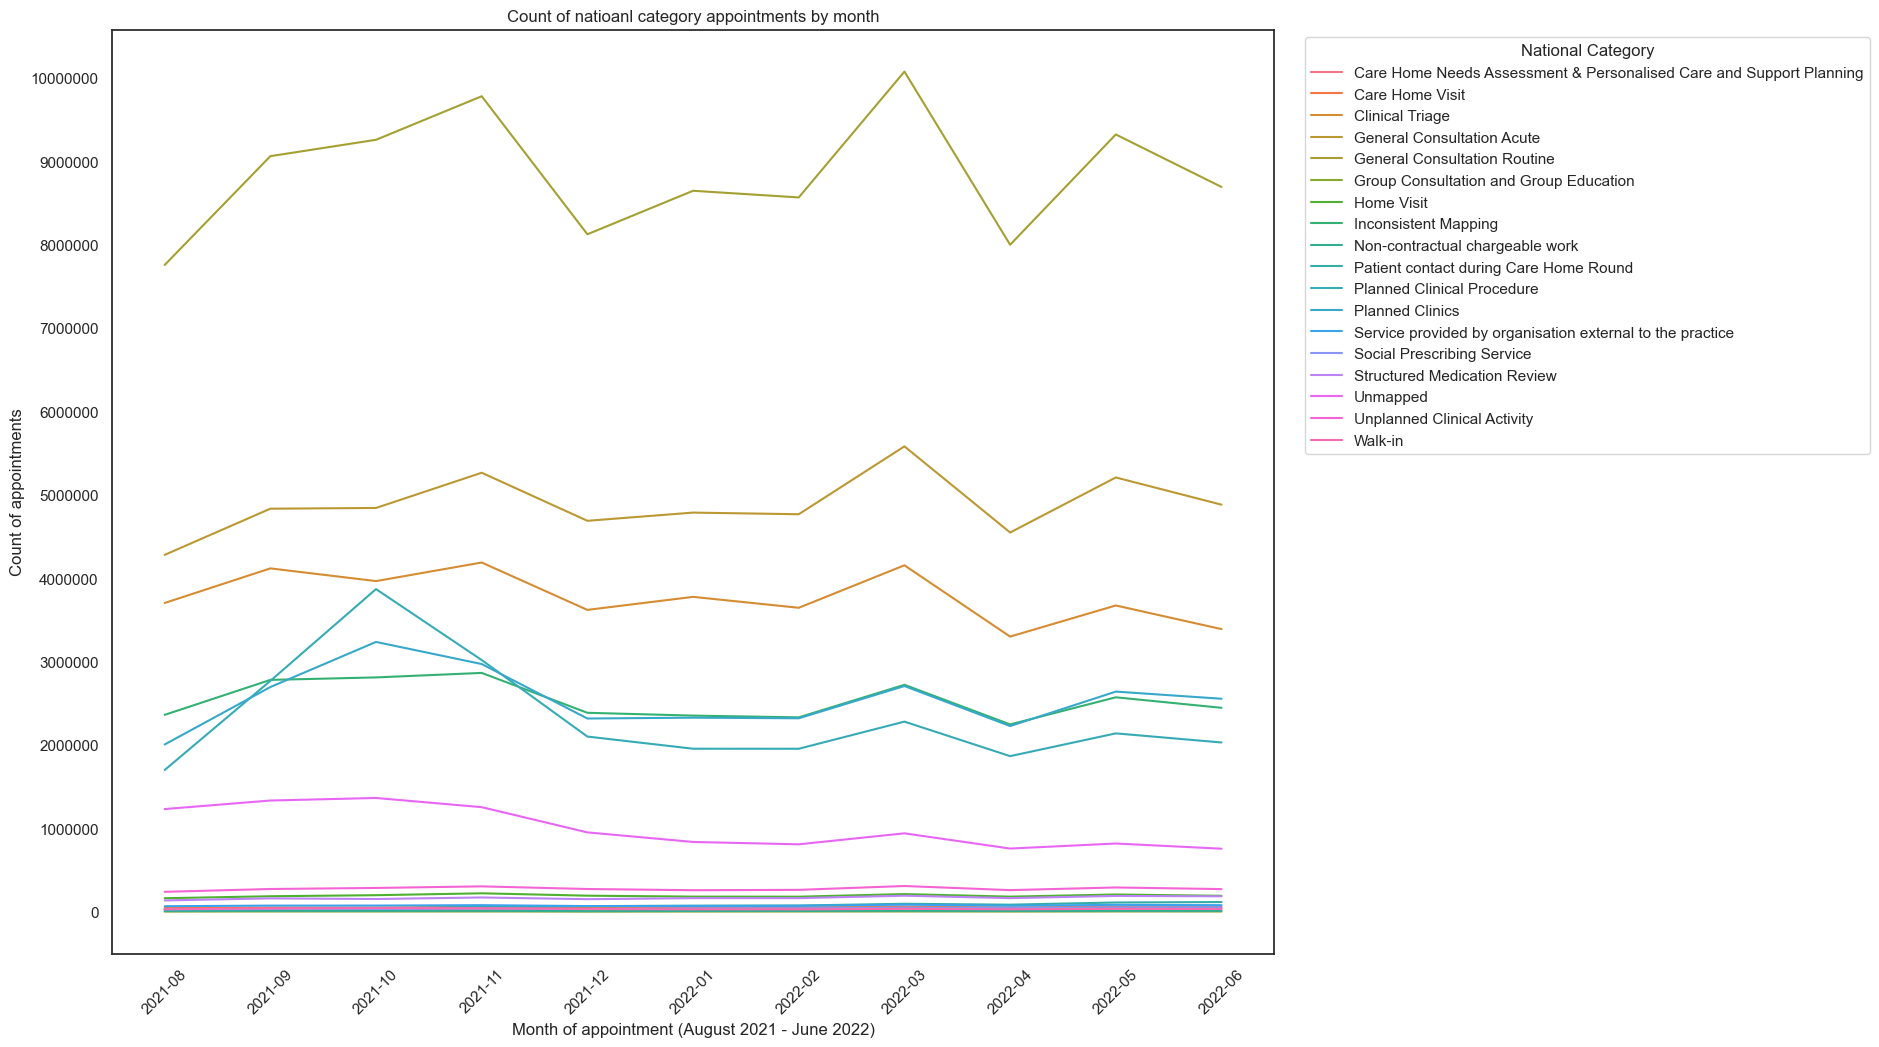

In [64]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
ax = sns.lineplot(data=nc_nc,
             x='appointment_month',
             y='count_of_appointments',
             hue='national_category')

# Format the plot.
ax.set_title('Count of natioanl category appointments by month')
ax.legend(title='National Category',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Month of appointment (August 2021 - June 2022)')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('national category by month.png')

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [65]:
# Create a separate data set that can be used in future weeks. 
nc_ss_day = (nc.groupby(['appointment_date', 
                         'appointment_month',
                         'service_setting'])
             ['count_of_appointments']
             .sum()
             .reset_index())

# View output.
nc_ss_day.head()

,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08,Extended Access Provision,438
1,2021-08-01,2021-08,General Practice,3411
2,2021-08-01,2021-08,Other,401
3,2021-08-01,2021-08,Primary Care Network,323
4,2021-08-01,2021-08,Unmapped,1054


In [66]:
# Create a summer filtered subset.
nc_ss_day_summer = nc_ss_day[(nc_ss_day['appointment_month'] >= '2021-06')
    &
    (nc_ss_day['appointment_month'] <='2021-08')]

# View filtered subset.
nc_ss_day_summer.head()

,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08,Extended Access Provision,438
1,2021-08-01,2021-08,General Practice,3411
2,2021-08-01,2021-08,Other,401
3,2021-08-01,2021-08,Primary Care Network,323
4,2021-08-01,2021-08,Unmapped,1054


<function matplotlib.pyplot.show(close=None, block=None)>

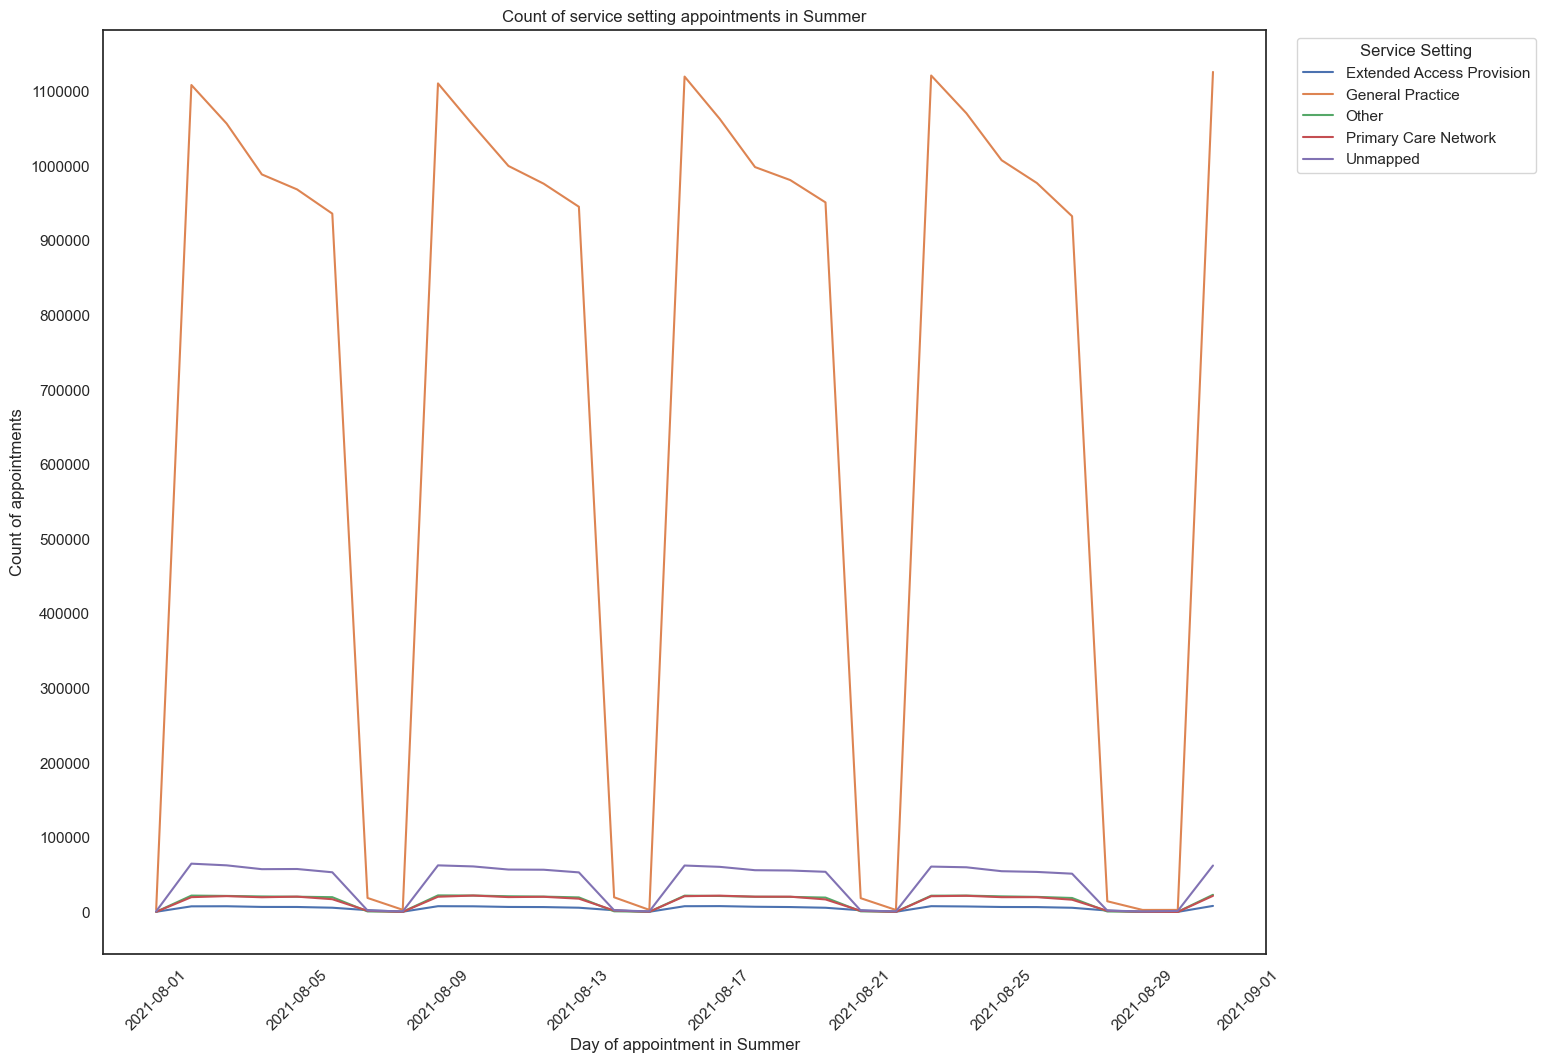

In [67]:
# Look at June to August 2021 in more detail to allow a closer look.
# Create a lineplot.
ax = sns.lineplot(data=nc_ss_day_summer,
             x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
            errorbar=None)

# Format the plot.
ax.set_title('Count of service setting appointments in Summer')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Day of appointment in Summer')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('summer service setting.png')
plt.show

The dataset does not have June and July in the time period, so the above plot only shows the appointments for August distributed over the days. The up and down nature of the plot shows that there were no appointments at the weekend.



**Autumn (September to November 2021):**

In [68]:
# Create a filtered subset for autumn.
nc_ss_day_autumn = nc_ss_day[(nc_ss_day['appointment_month'] >= '2021-09')
    &
    (nc_ss_day['appointment_month'] <= '2021-11')]

# View filtered subset.
nc_ss_day_autumn.head()

,appointment_date,appointment_month,service_setting,count_of_appointments
155,2021-09-01,2021-09,Extended Access Provision,6916
156,2021-09-01,2021-09,General Practice,1041879
157,2021-09-01,2021-09,Other,21796
158,2021-09-01,2021-09,Primary Care Network,21371
159,2021-09-01,2021-09,Unmapped,57423


<function matplotlib.pyplot.show(close=None, block=None)>

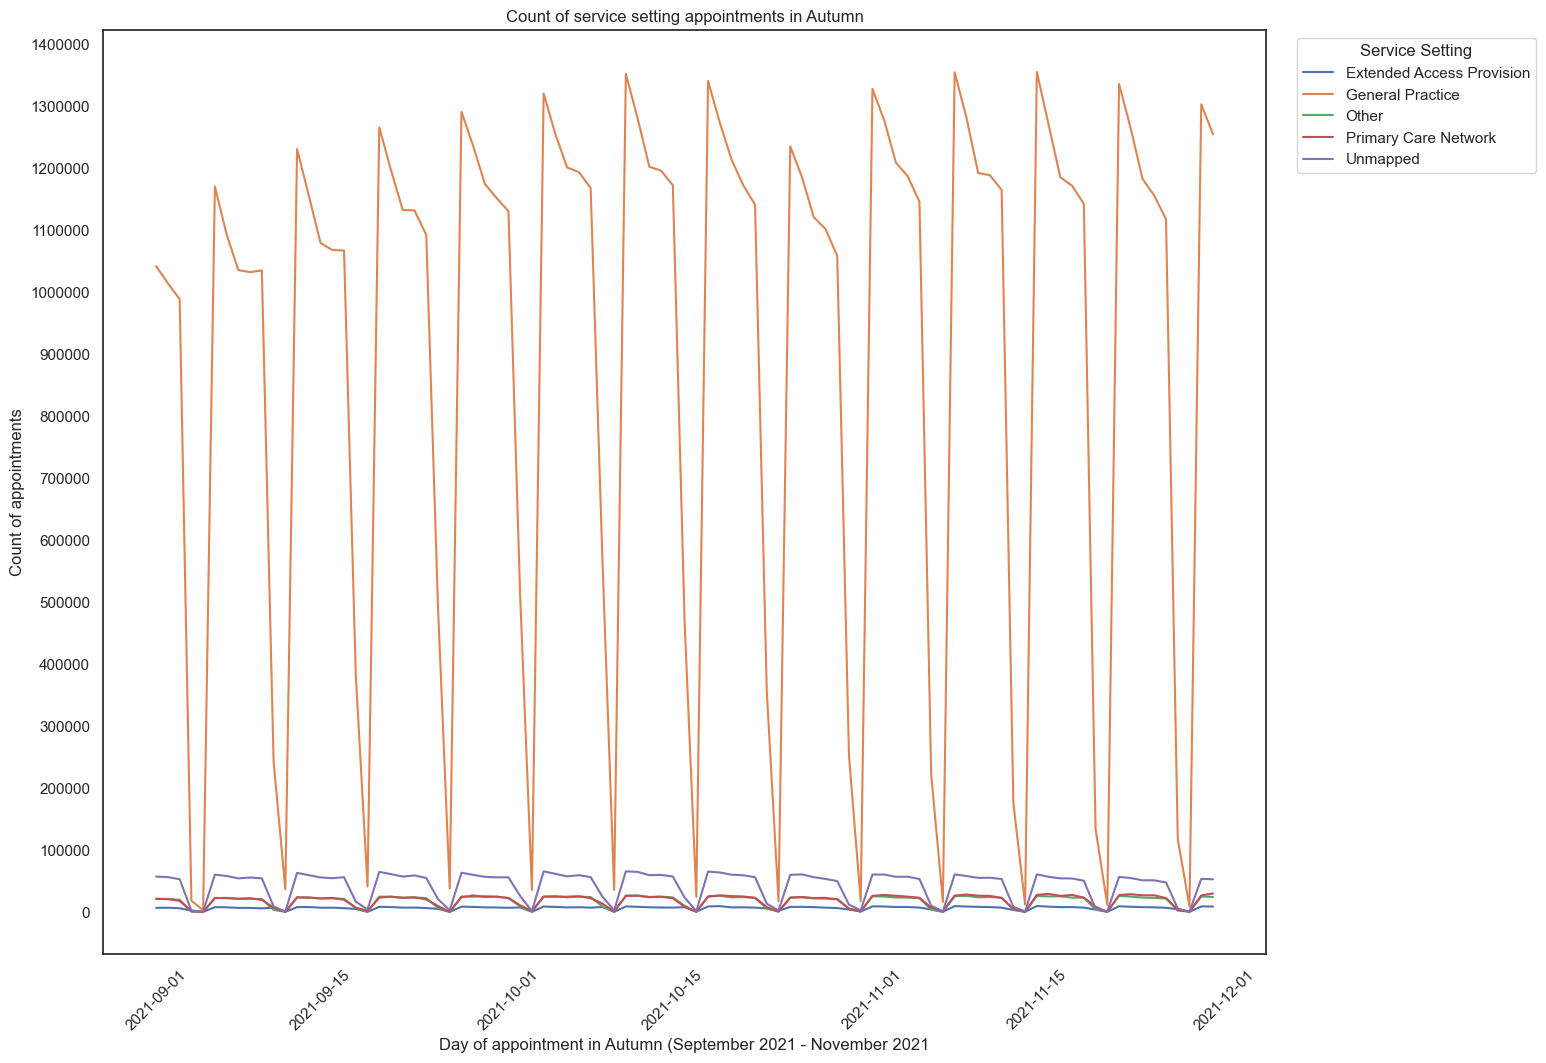

In [69]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.
ax = sns.lineplot(data=nc_ss_day_autumn,
             x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Format the plot.
ax.set_title('Count of service setting appointments in Autumn')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Day of appointment in Autumn (September 2021 - November 2021')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('Autumn service setting.png')
plt.show

The peak of each week increases week by week, but there seems to be a big drop in the last week of October. It picks up after that. The steady increase shows that the NHS is needed more often as we come in to the winter.

**Winter (December to February 2022):**

In [70]:
# Create a filtered subset for Winter.
nc_ss_day_winter = nc_ss_day[(nc_ss_day['appointment_month'] >= '2021-12')
    &
    (nc_ss_day['appointment_month'] <= '2022-02')]

# View the filtered dateset.
nc_ss_day_winter.head()

,appointment_date,appointment_month,service_setting,count_of_appointments
610,2021-12-01,2021-12,Extended Access Provision,8500
611,2021-12-01,2021-12,General Practice,1162676
612,2021-12-01,2021-12,Other,22924
613,2021-12-01,2021-12,Primary Care Network,26887
614,2021-12-01,2021-12,Unmapped,49064


<function matplotlib.pyplot.show(close=None, block=None)>

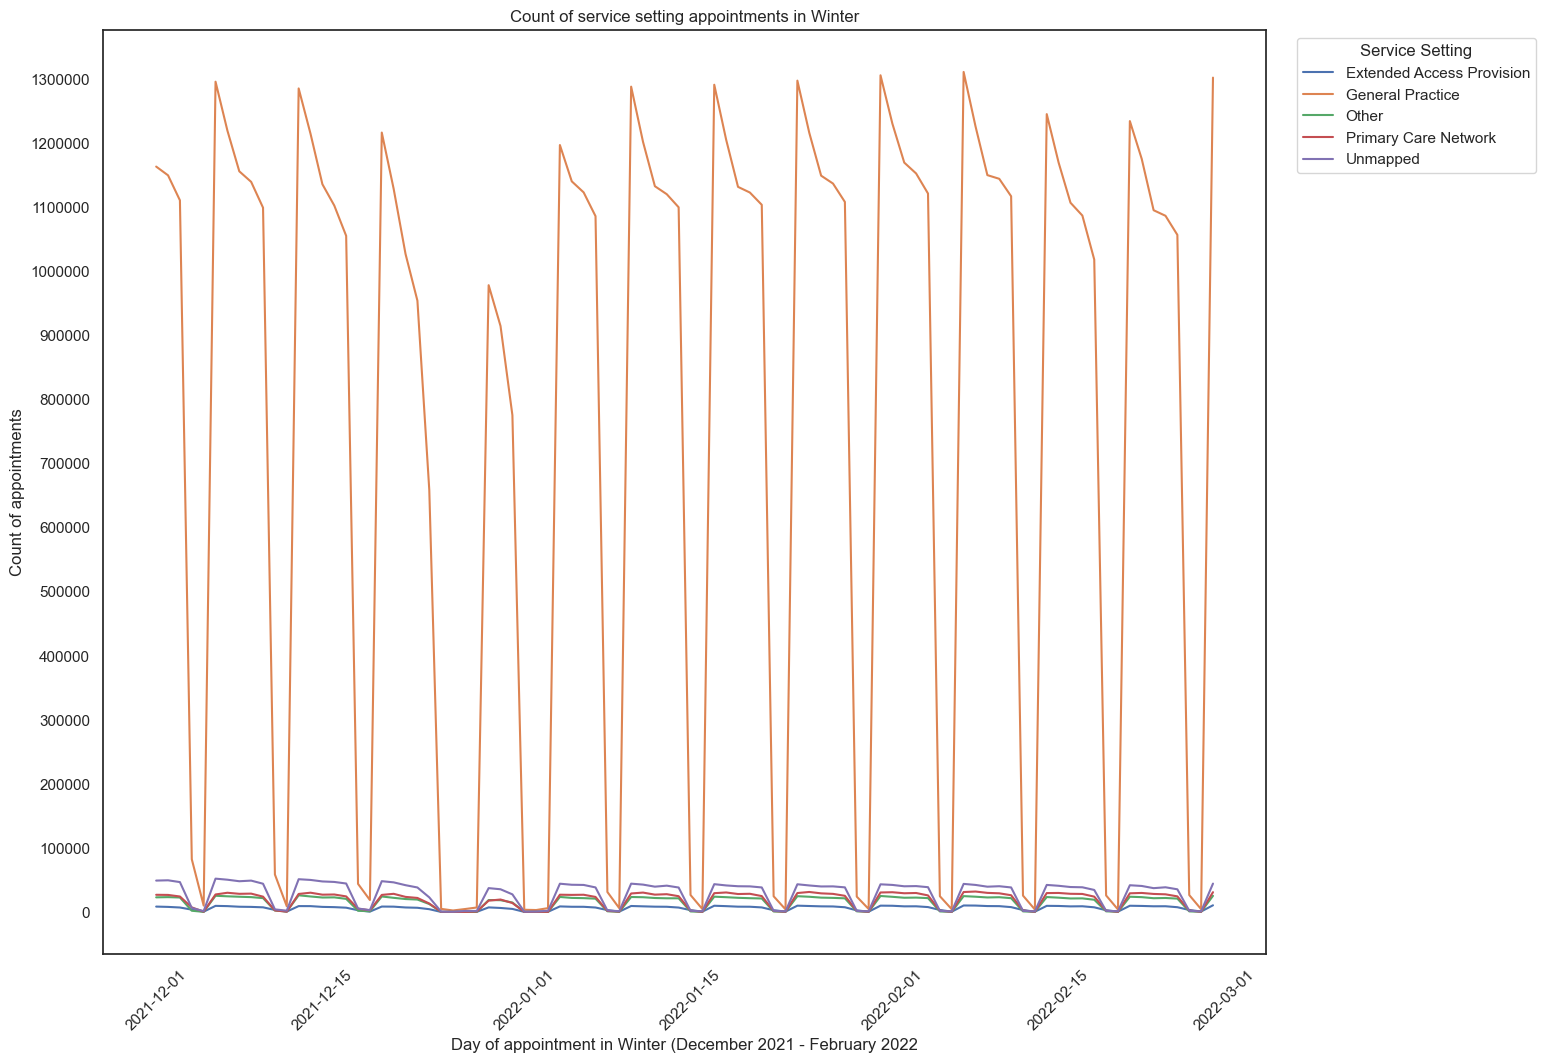

In [71]:
# Look at December to February 2022 in more detail to allow a closer look.
# Create a lineplot.
ax = sns.lineplot(data=nc_ss_day_winter,
             x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Format the plot.
ax.set_title('Count of service setting appointments in Winter')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Day of appointment in Winter (December 2021 - February 2022')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('Winter Summer setting.png')
plt.show

It shows that capacity is taken up a lot as it is in Winter. Interesting that the usage goes down for the week between christmas and new year, but doesn't stop. The long weekends show no usage at all for extended periods.

**Spring (March to May 2022):**

In [72]:
# Create a filtered subset for Spring.
nc_ss_day_spring = nc_ss_day[(nc_ss_day['appointment_month'] >= '2022-03')
    &
    (nc_ss_day['appointment_month'] <= '2022-05')]

# View the filtered DataFrame.
nc_ss_day_spring.head()

,appointment_date,appointment_month,service_setting,count_of_appointments
1060,2022-03-01,2022-03,Extended Access Provision,10082
1061,2022-03-01,2022-03,General Practice,1229045
1062,2022-03-01,2022-03,Other,23986
1063,2022-03-01,2022-03,Primary Care Network,32070
1064,2022-03-01,2022-03,Unmapped,42682


<function matplotlib.pyplot.show(close=None, block=None)>

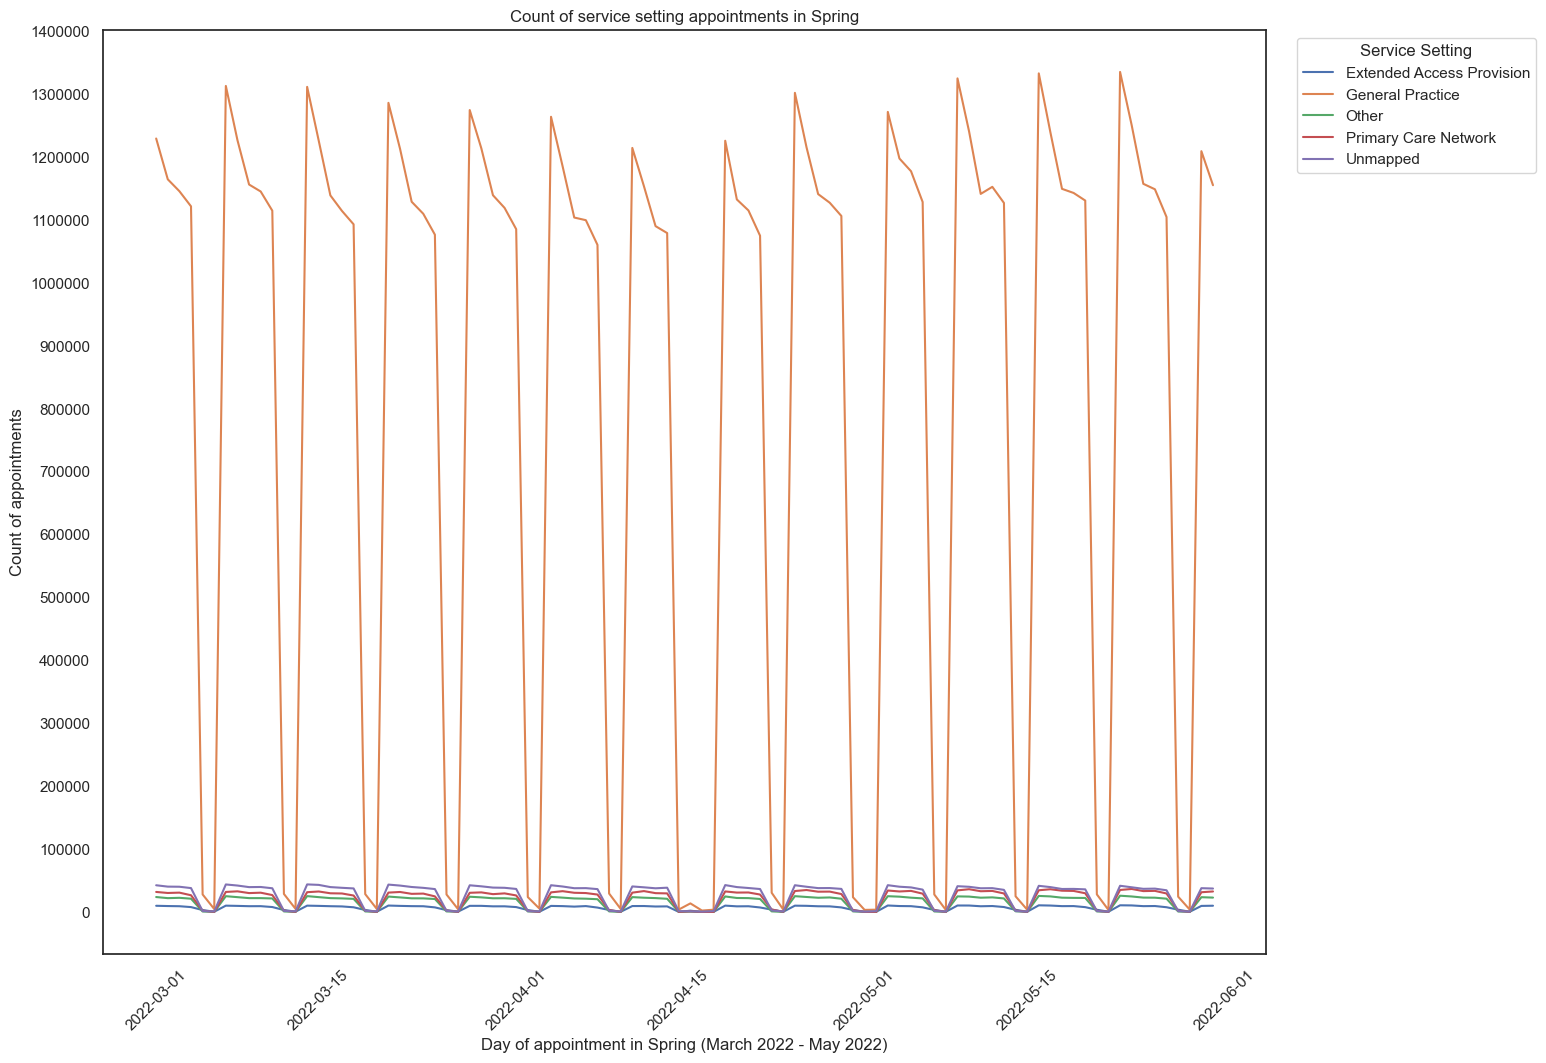

In [73]:
# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot.
ax = sns.lineplot(data=nc_ss_day_spring,
             x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Format the plot.
ax.set_title('Count of service setting appointments in Spring')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Day of appointment in Spring (March 2022 - May 2022)')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.savefig('Spring Service setting.png')
plt.show


The trend starts to decrease as we go towards the warmer months, however, it starts to pick up again after the long weekend of the may bank holiday.

<function matplotlib.pyplot.show(close=None, block=None)>

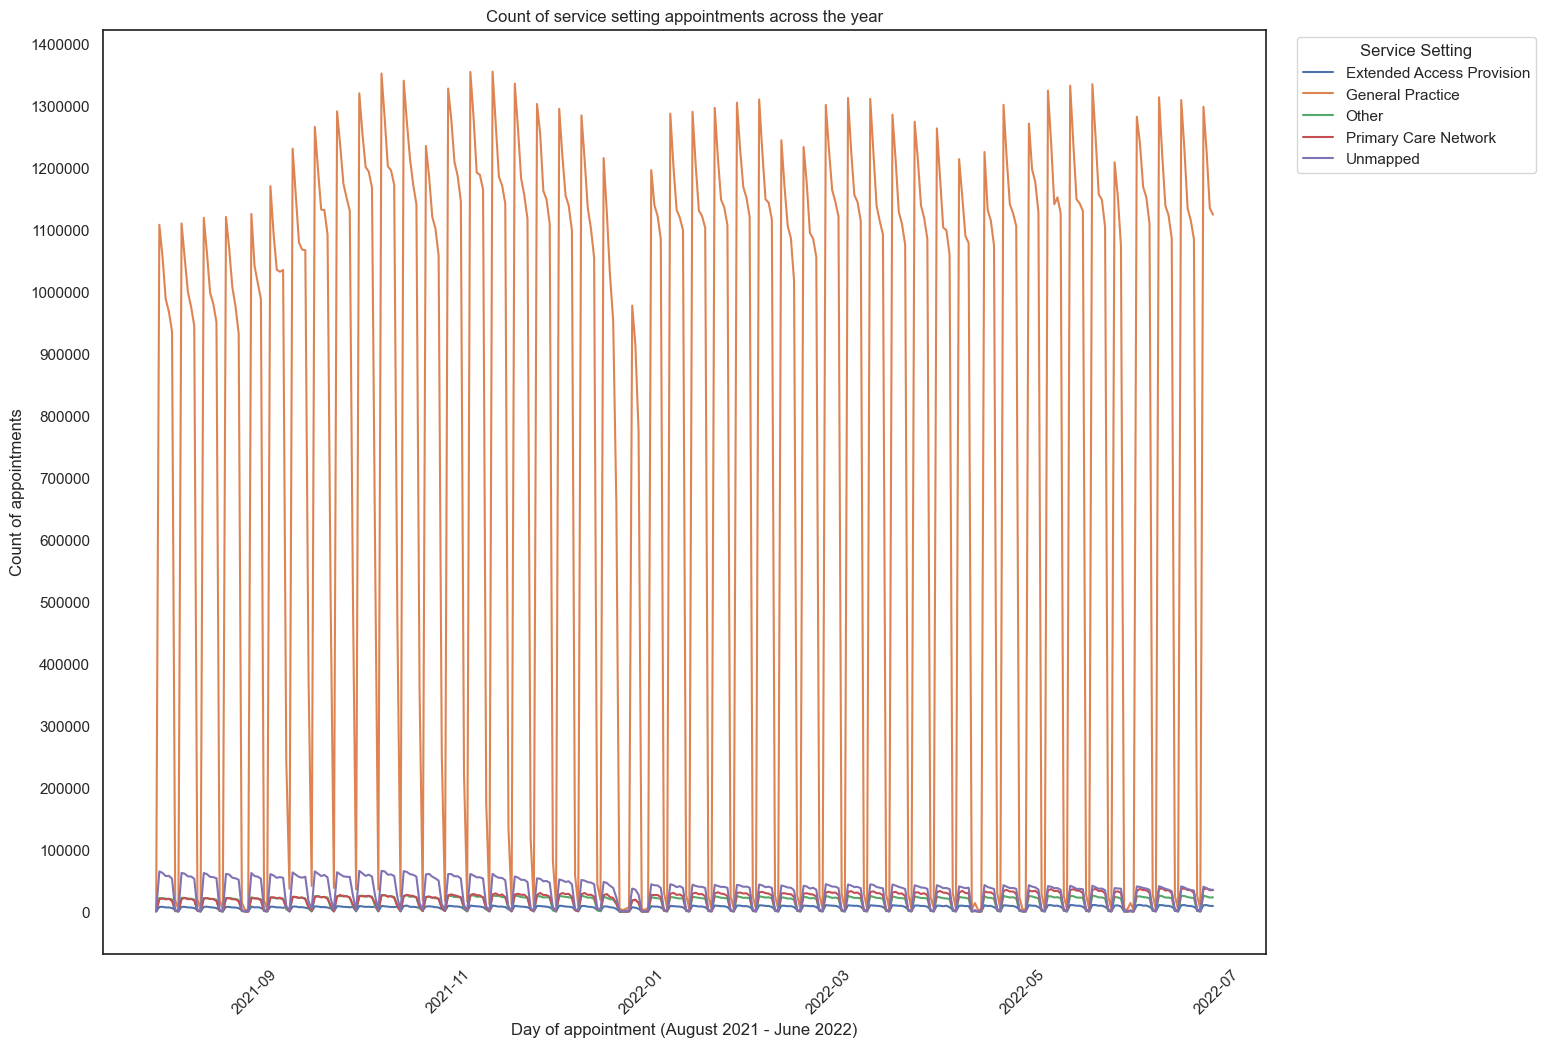

In [74]:
# Create a lineplot of the whole dataset.
ax = sns.lineplot(data=nc_ss_day,
             x='appointment_date',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Format the plot.
ax.set_title('Count of service setting appointments across the year')
ax.legend(title='Service Setting',
         bbox_to_anchor=(1.02,1),
         loc='upper left')
ax.set_xlabel('Day of appointment (August 2021 - June 2022)')
ax.set_ylabel('Count of appointments')
plt.ticklabel_format(axis='y',style='plain')
plt.locator_params(axis='y', nbins=20)
plt.locator_params(axis='x', nbins=12)
plt.xticks(rotation=45)
plt.savefig('daily service setting.png')
plt.show

This shows the year long trend, that shows increases after the summer months (in the autumn), however it stays high in to the following year's summer months.

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [75]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [76]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
print(tweets.shape)
print(tweets.dtypes)
print(tweets.columns)
tweets.head()

(1174, 10)
tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count         int64
tweet_favorite_count        int64
tweet_favorited              bool
tweet_retweeted              bool
tweet_lang                 object
dtype: object
Index(['tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'],
      dtype='object')


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [77]:
# Explore the metadata.
print(tweets.info())
print(tweets.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std

In [78]:
# Explore the data set. 
print(tweets['tweet_retweet_count'].value_counts())
print(tweets['tweet_favorite_count'].value_counts())
print(tweets[['tweet_retweet_count','tweet_favorite_count']].value_counts())

tweet_retweet_count
0      526
1      215
2      114
3       70
5       35
4       27
7       18
12      16
8       15
73      14
9       13
6       12
208     12
35      10
37       6
11       6
10       5
53       5
44       4
150      4
63       4
76       3
85       3
41       3
62       3
207      3
68       3
78       2
23       2
24       2
72       2
16       2
13       1
49       1
48       1
15       1
107      1
14       1
79       1
20       1
39       1
19       1
303      1
57       1
40       1
54       1
169      1
Name: count, dtype: int64
tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
17       1
12       1
10       1
8        1
13       1
11       1
7        1
20       1
28       1
14       1
18       1
9        1
42       1
Name: count, dtype: int64
tweet_retweet_count  tweet_favorite_count
0                    0                       436
1                    0                       189
2                    0        

# Would it be useful to only look at retweeted and favourite tweet messages?
There are 436 tweets that have no interactions. It would be interesting to see the context of the tweets that have recieved large amounts of favourites and retweets.


In [79]:
# Create a new DataFrame containing only the text.
tweets_text = tweets.select_dtypes(
    include='object').copy()

# View the DataFrame.
tweets_text.head()

,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_lang
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",en
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",en


In [80]:
# Create  an empty list
tags = []

# Loop through the messages, and create a list of values containing the # symbol.
for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            tags.append(z.lower())

In [81]:
# Create a Series with the list.
tags = pd.Series(tags).value_counts()
# Display the first 30 records.
tags.head(30)

#healthcare                    716
#health                         80
#medicine                       41
#ai                             40
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#medtwitter                     24
#biotech                        24
#competitiveintelligence        24
#meded                          23
#vaccine                        18
#hiring                         18
#news                           17
#machinelearning                17
#technology                     17
#coronavirus                    16
#womeninmedicine                16
#covid                          16
#competitivemarketing           16
#wellness                       15
#healthtech                     15
#doctorofveterinarymedicine     14
#science                        14
#medicare           

In [82]:
# Convert the series to a DataFrame in preparation for visualisation.
tags = tags.to_frame()

# View the new DataFrame.
tags.head()

,count
#healthcare,716
#health,80
#medicine,41
#ai,40
#job,38


In [83]:
# Rename the columns.
tags = tags.reset_index()
tags.columns=['Word', 'Count']

# View the DataFrame.
tags

,Word,Count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
...,...,...
1749,#evestudy,1
1750,#patientdata…,1
1751,#secure,1
1752,#sms,1


In [84]:
# Check the datatypes.
tags.dtypes

Word     object
Count     int64
dtype: object

In [85]:
# Display records where the count is larger than 10.
filtered_tags = tags[tags['Count'] > 10]

<Axes: xlabel='Count', ylabel='Word'>

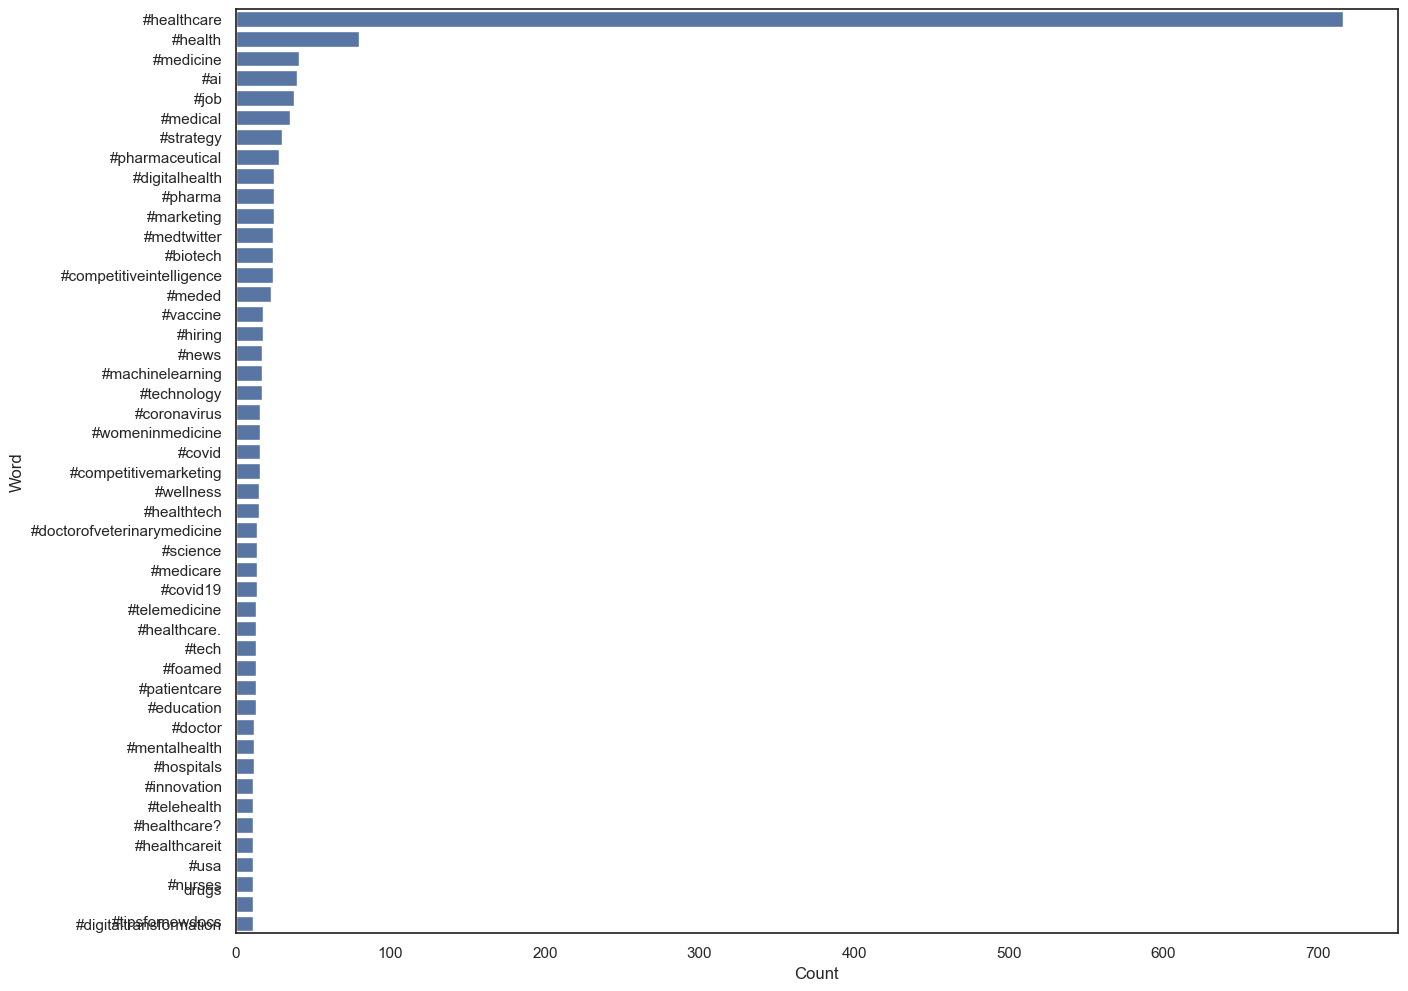

In [86]:
# Create a Seaborn barplot indicating records with a count >10 records.
sns.barplot(data=filtered_tags,
            x='Count',
            y='Word')

In [87]:
# Filter out the top two words.
filtered_tags = filtered_tags[filtered_tags['Word'] != '#healthcare']
filtered_tags = filtered_tags[filtered_tags['Word'] != '#health']

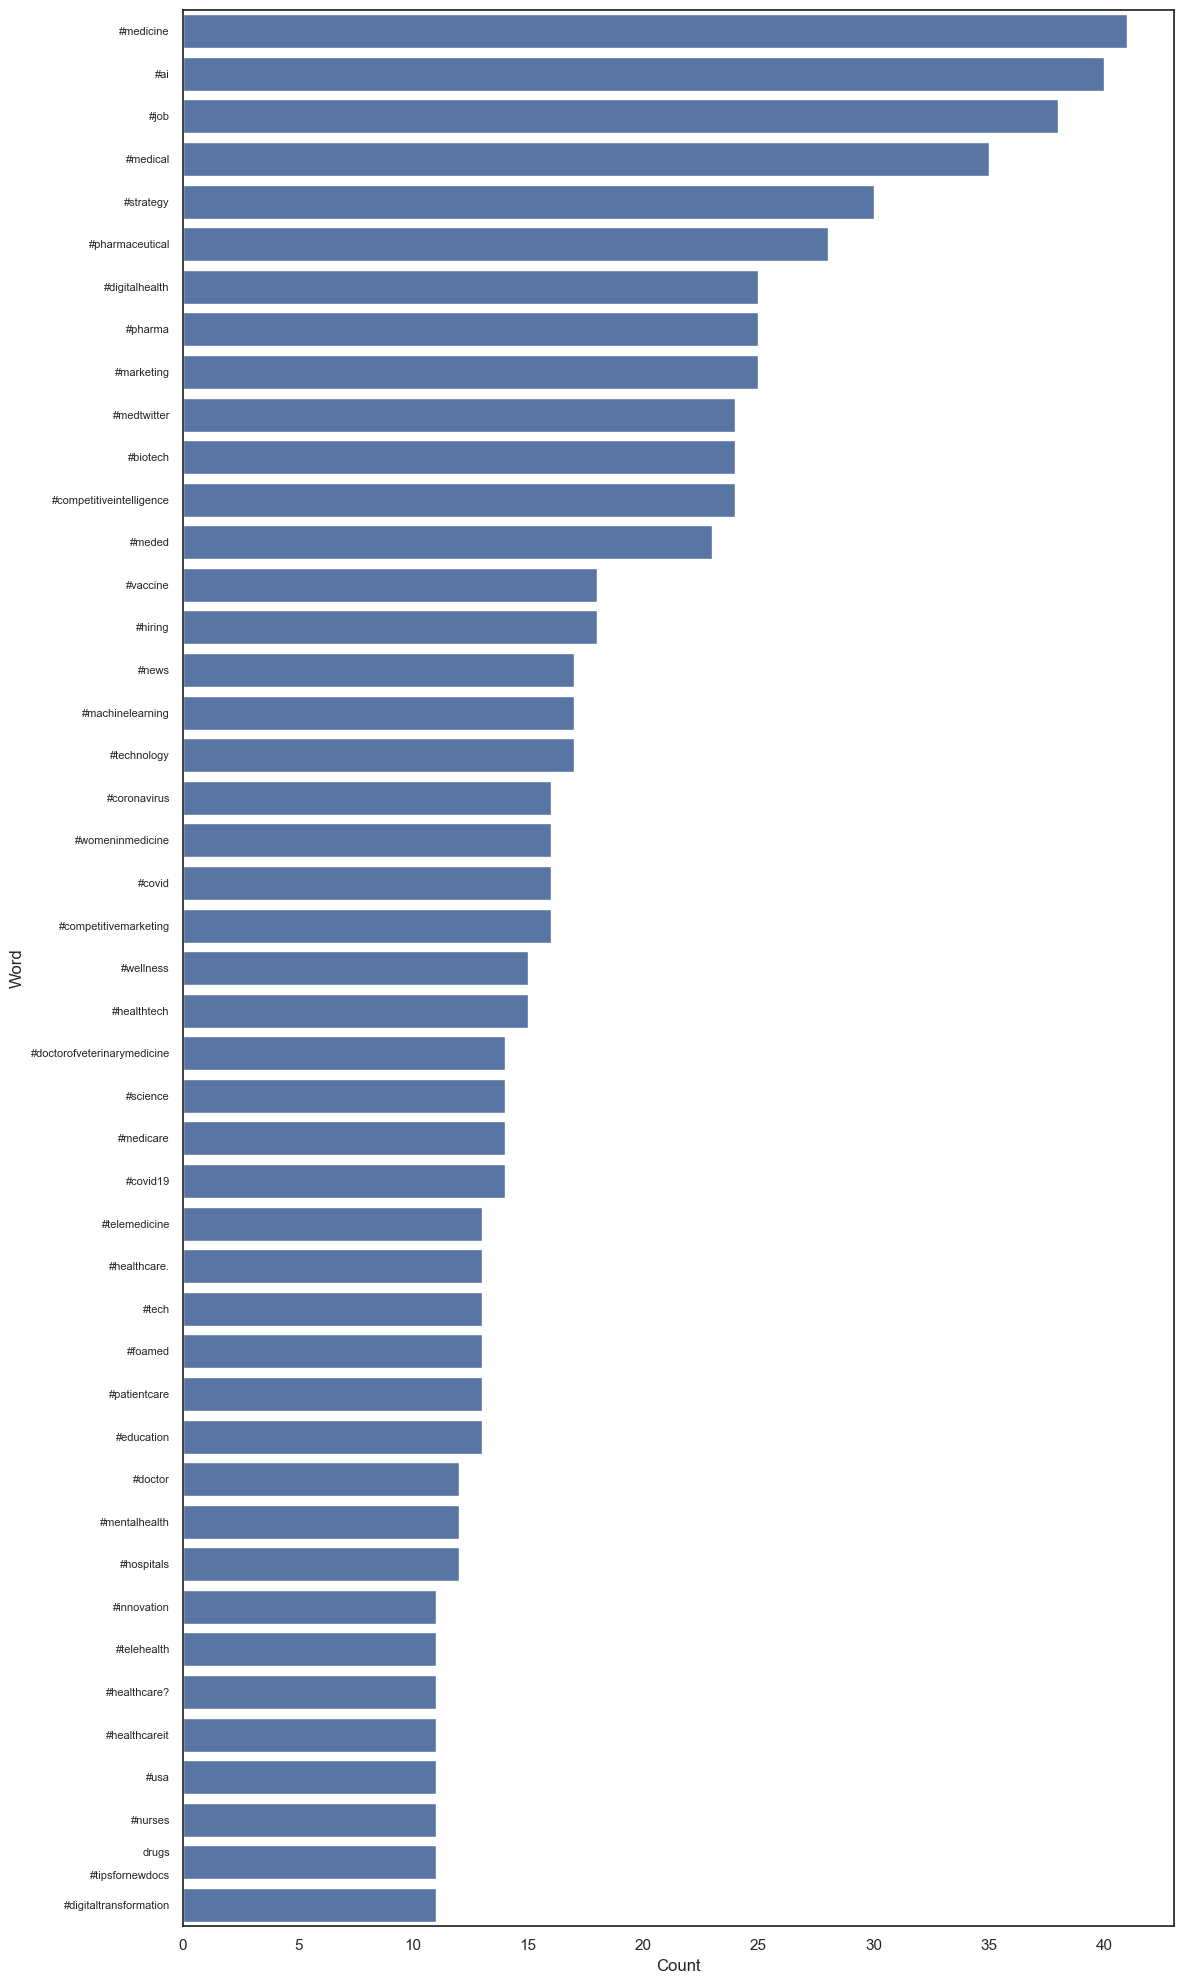

<Figure size 1500x1200 with 0 Axes>

In [88]:
# Create plot 
# Make plot taller to fit all y-axis labels.
plt.figure(figsize=(12,20))

sns.barplot(
    data=filtered_tags,
    x='Count',
    y='Word')

# Format plot.
plt.yticks(fontsize=8)

plt.tight_layout()

plt.show()
plt.savefig('tweets.png')

The hashtags are mainly focused on america, such as #usa. There are also hashtags that are involved that may not be related to health, such as #innovation. 

# Assignment activity 6

### Make recommendations to the NHS. 

In [89]:
# Looking at the appointments_regional data set.
# View the DataFrame.
ar.head(5)

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2020-01-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2020-01-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2020-01-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2020-01-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2020-01-01


In [90]:
# Print the min and max dates.
print(f"""Earliest month in the appointments_regional dataset: {ar['appointment_month'].min()}""")
print("")
print(f"""Latest month in the appointments_regional dataset: {ar['appointment_month'].max()}""")

Earliest month in the appointments_regional dataset: 2020-01

Latest month in the appointments_regional dataset: 2022-06


In [91]:
# Filter the data set to only look at data from 2021-08 onwards.
ar = ar[ar['appointment_month'] >= '2021-08']

**Question 1:** Should the NHS start looking at increasing staff levels? 

In [92]:
# Create an aggregated data set to review the different features.
ar_agg = ar.groupby(['appointment_month',
                      'hcp_type',
                      'appointment_status',
                      'appointment_mode',
                      'time_between_book_and_appointment'])\
['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [93]:
# Determine the total number of appointments per month.
ar_df = ar_agg.groupby(['appointment_month'])\
['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_df.head()

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776


In [94]:
# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_df['average_utilisation'] = (ar_df['count_of_appointments']
                                /
                                30)\
    .round(1)

# View the DataFrame.
ar_df

,appointment_month,count_of_appointments,average_utilisation
0,2021-08,23852171,795072.4
1,2021-09,28522501,950750.0
2,2021-10,30303834,1010127.8
3,2021-11,30405070,1013502.3
4,2021-12,25140776,838025.9
5,2022-01,25635474,854515.8
6,2022-02,25355260,845175.3
7,2022-03,29595038,986501.3
8,2022-04,23913060,797102.0
9,2022-05,27495508,916516.9


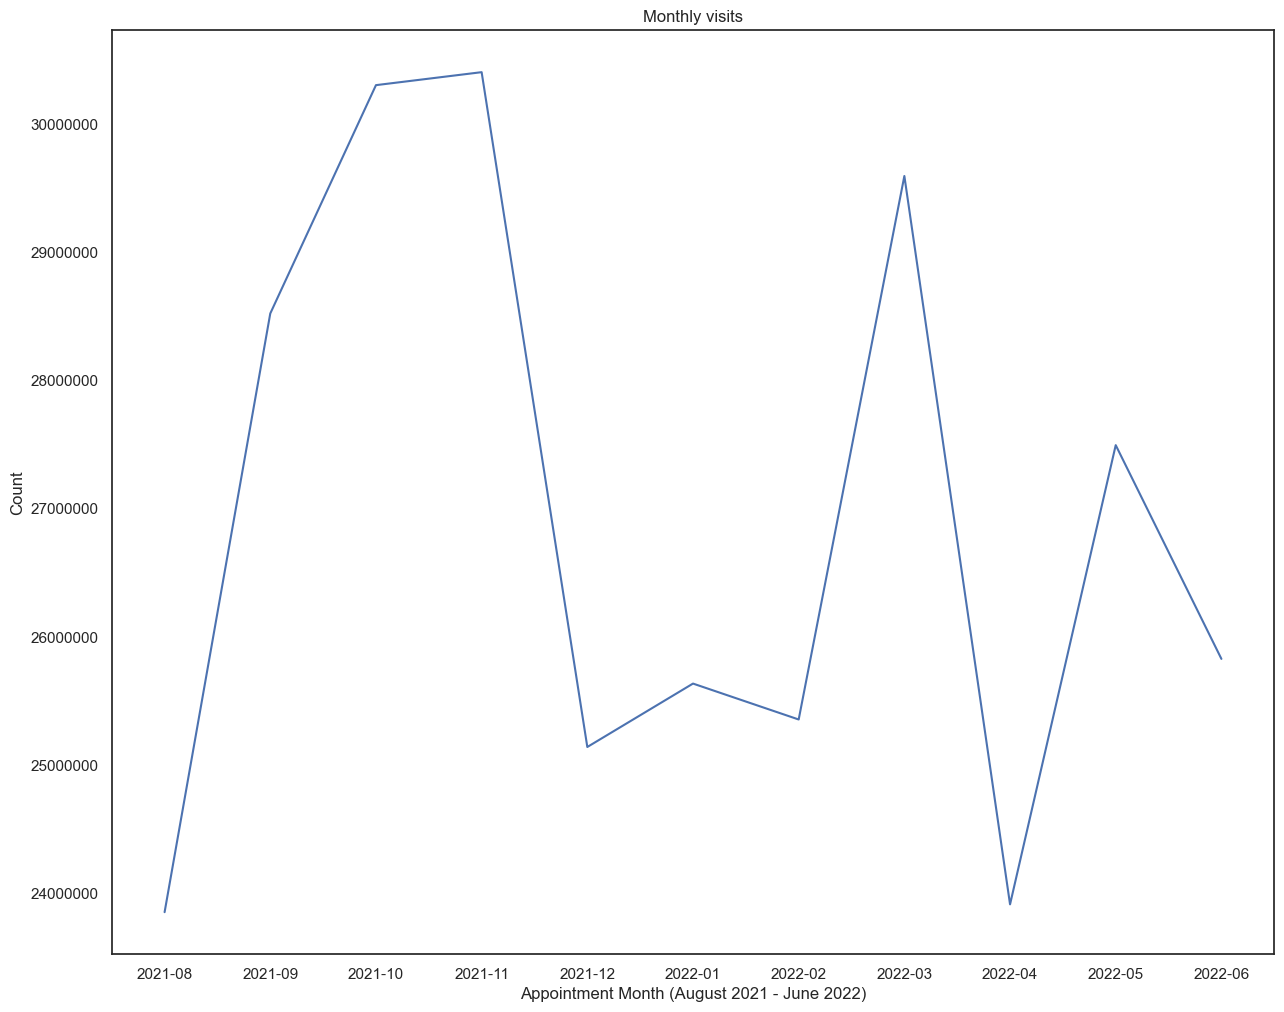

In [95]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_df['appointment_month'] = ar_df['appointment_month'].astype(str)

# Create a lineplot with Seaborn.
ax = sns.lineplot(data=ar_df,
                  x='appointment_month',
                  y='count_of_appointments')

# Format the plot.
ax.set_title('Monthly visits')
ax.set_ylabel('Count')
ax.set_xlabel('Appointment Month (August 2021 - June 2022)')
plt.ticklabel_format(axis='y',style='plain')
plt.savefig('Monthly visits.png')

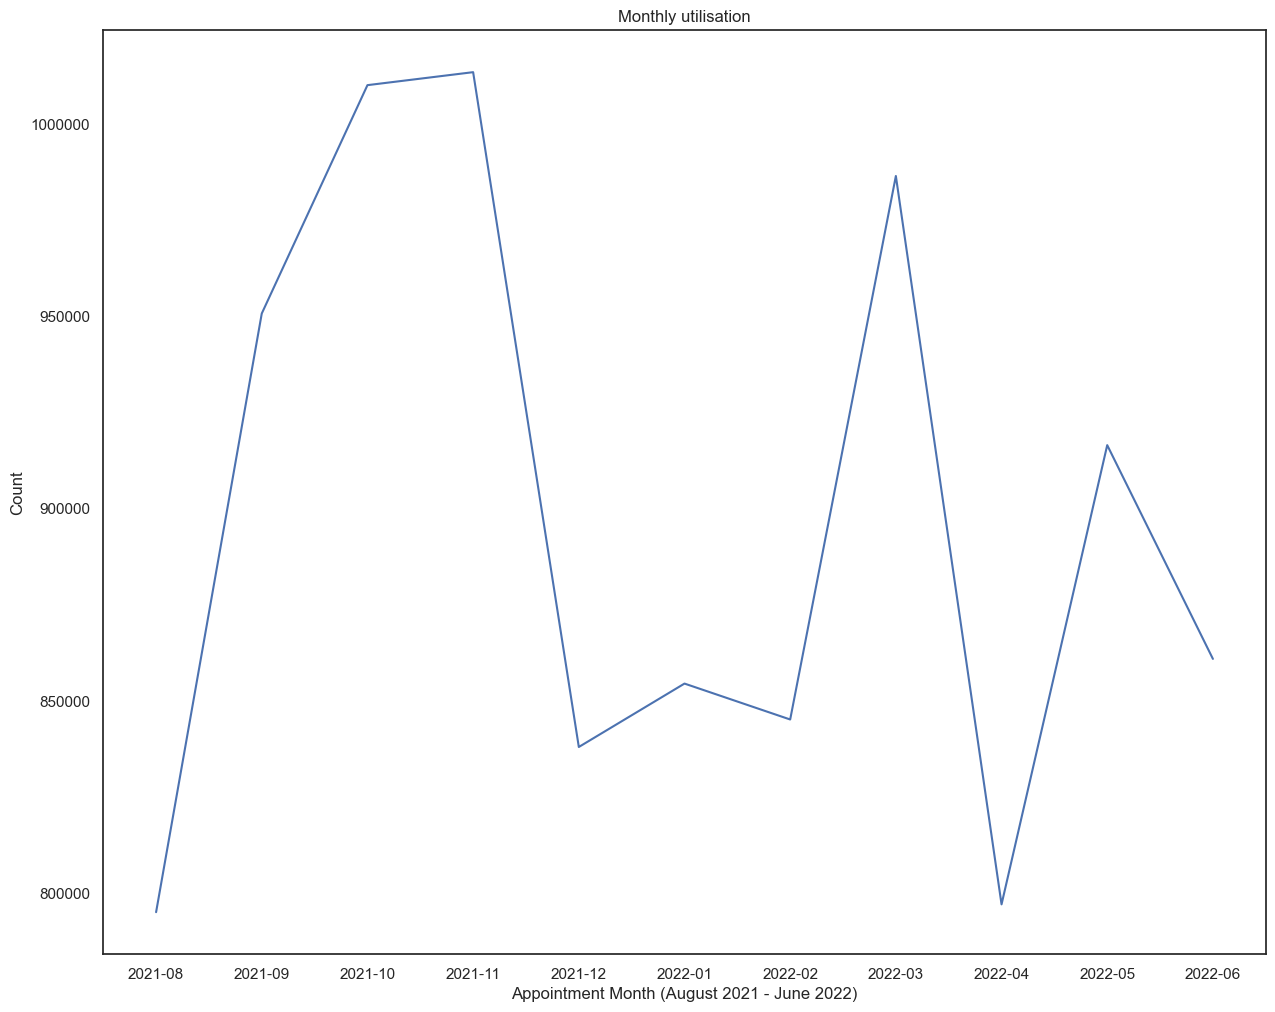

In [96]:
# Plot monthly capacity utilisation.
ax = sns.lineplot(data=ar_df,
                  x='appointment_month',
                  y='average_utilisation')

# Format the plot.
ax.set_title('Monthly utilisation')
ax.set_ylabel('Count')
ax.set_xlabel('Appointment Month (August 2021 - June 2022)')
plt.ticklabel_format(axis='y',style='plain')
plt.savefig('Monthly utilisation.png')

**Question 1:** Should the NHS start looking at increasing staff levels? 
During the summer months the resources are near capacity, but during the winter months, when the nhs is most stretched, the utilisation value is much lower. Perhaps with the increase in population it would be advisable to increase capacity, as it showed that the NHS was close to capacity before the winter squeeze.

**Question 2:** How do the healthcare professional types differ over time?

In [97]:
# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,398772


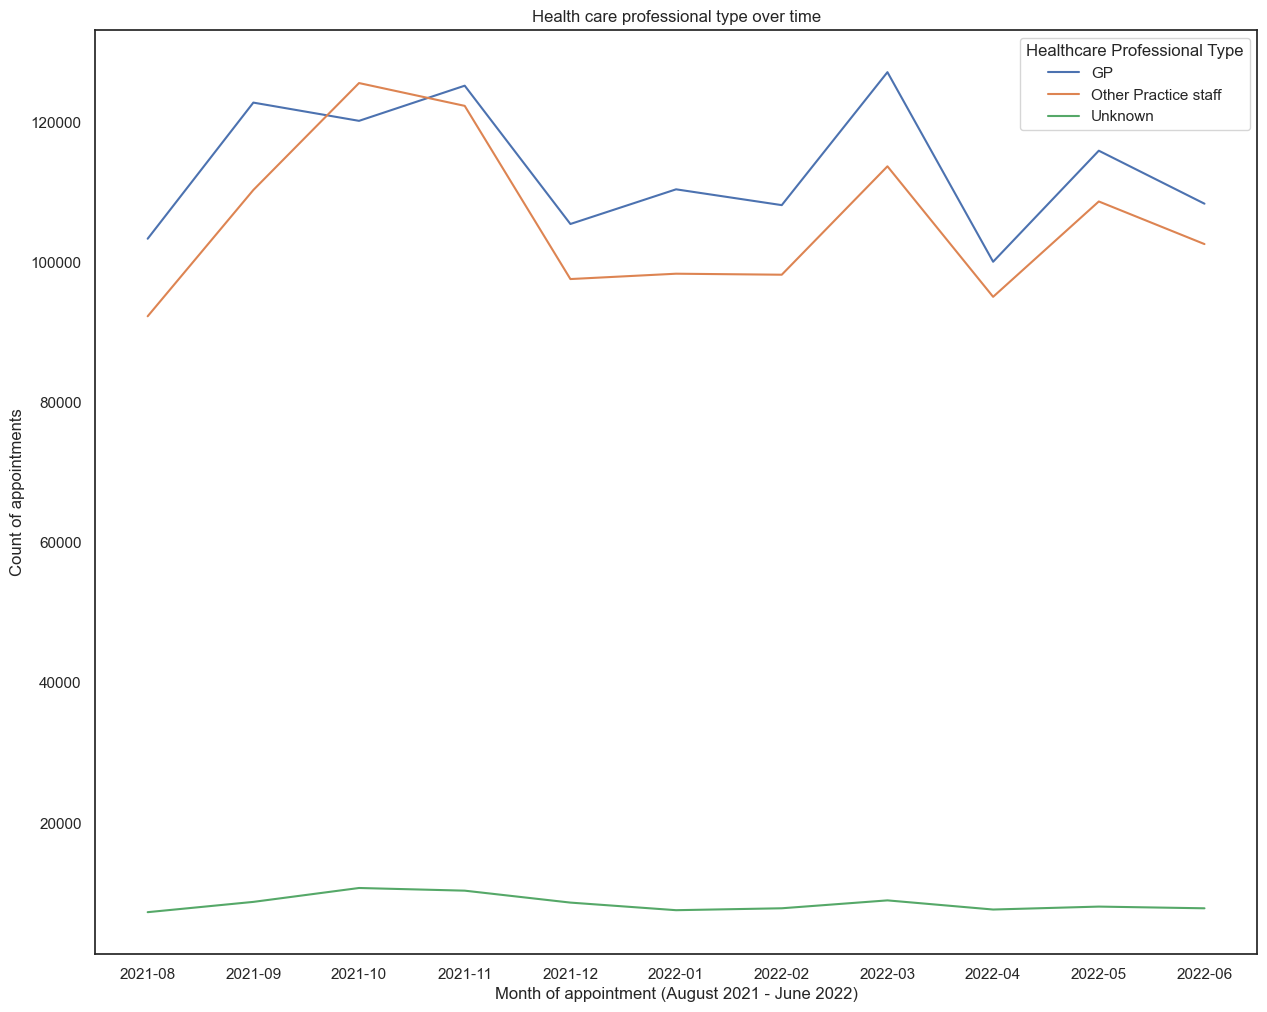

In [98]:
# Create a plot.
ax = sns.lineplot(data=ar_agg,
             x='appointment_month',
             y='count_of_appointments',
             hue='hcp_type',
             errorbar=None)

# Format the plot.
ax.set_title("Health care professional type over time")
ax.set_xlabel("Month of appointment (August 2021 - June 2022)")
ax.set_ylabel("Count of appointments")
plt.savefig("hcp over time.png")
ax.legend(title='Healthcare Professional Type')

**Question 2:** How do the healthcare professional types differ over time?
There are mostly GPs over the time period. This swaps with 'Other Practice Staff' in October 2021, but returns back to GPs being the most staffed appointments. There two healthcare professional types, General Practice and Other Practice Staff, follow a similar pattern.

**Question 3:** Are there significant changes in whether or not visits are attended?

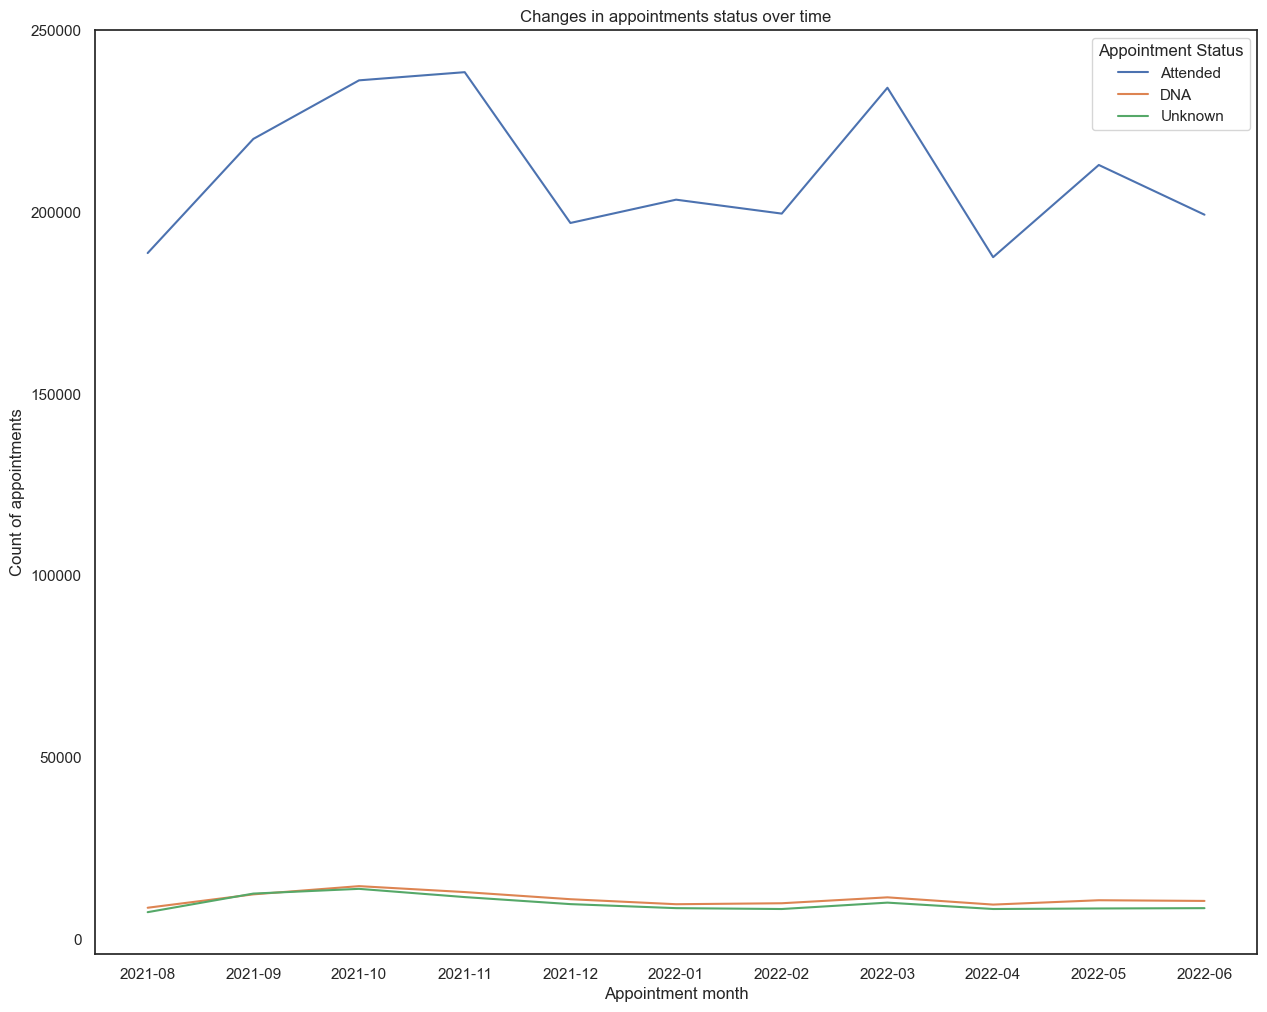

In [99]:
# Create a line plot to answer the question.
ax = sns.lineplot(data=ar_agg,
             x='appointment_month',
             y='count_of_appointments',
             hue='appointment_status',
             errorbar=None)

# Format the plot.
ax.set_title("Changes in appointments status over time")
ax.set_xlabel("Appointment month")
ax.set_ylabel("Count of appointments")
ax.legend(title="Appointment Status")
plt.savefig("Appointment status.png")

**Question 3:** Are there significant changes in whether or not visits are attended?
The attended line (blue) follows a similar path to the previous utilisation line plot. This suggests that the vast majority of appointments are attended. The lines for did not attend (orange) and unknown (green) follow a similar path, which suggests that the unknowns may be did not attends depending on the practice's data entry.


**Question 4:** Are there changes in terms of appointment type and the busiest months?

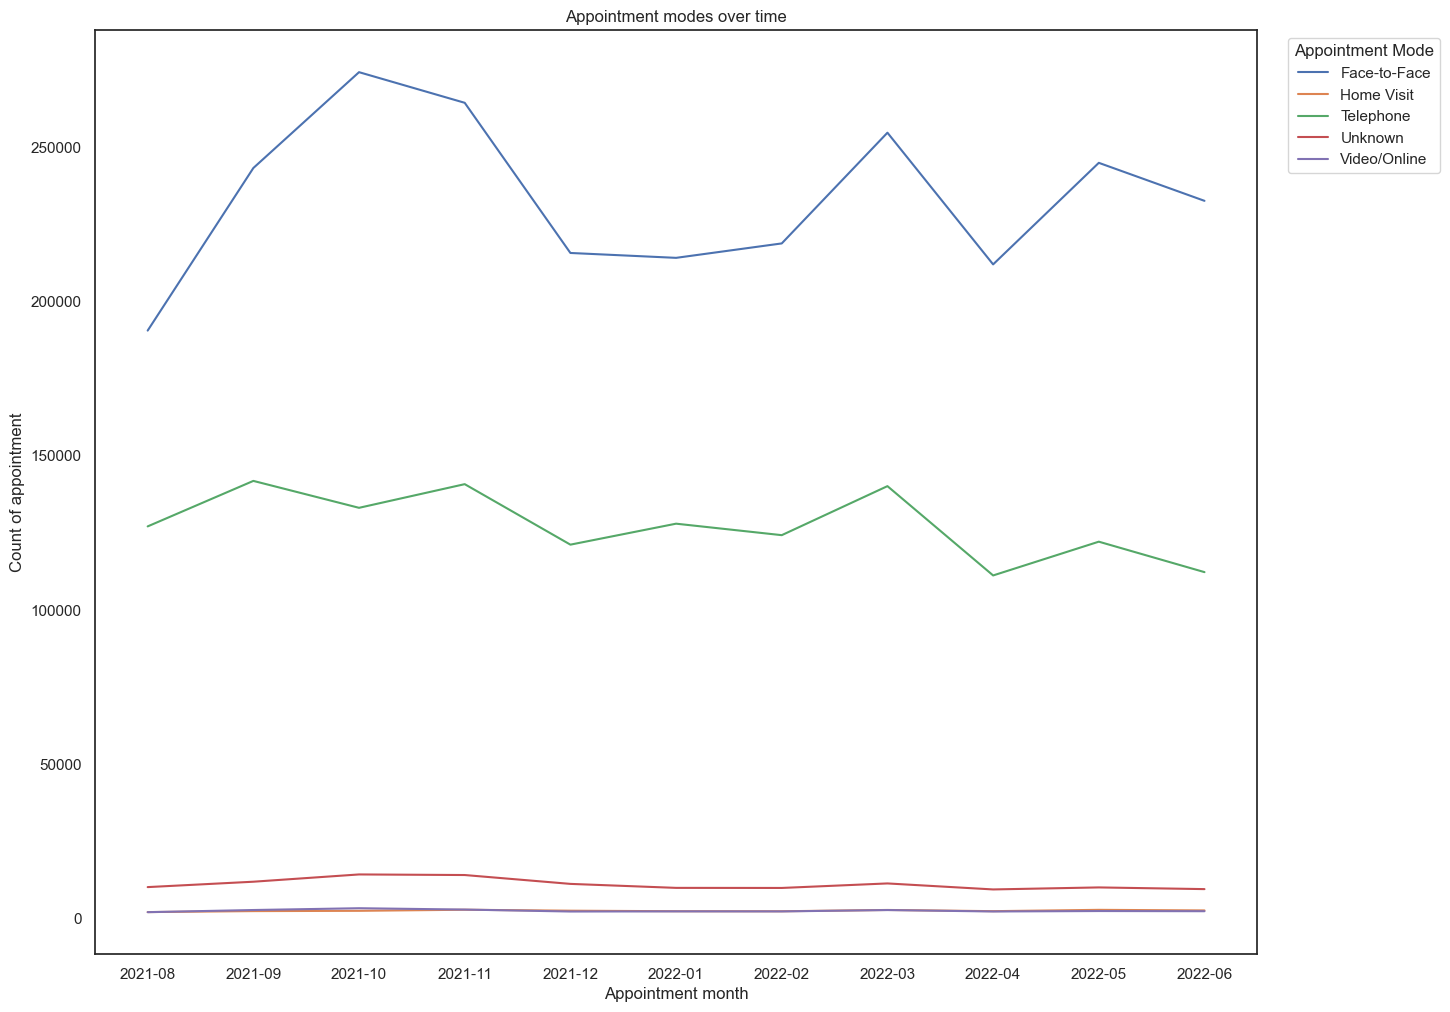

In [100]:
# Create a line plot to answer the question.
ax = sns.lineplot(data=ar_agg,
             x='appointment_month',
             y='count_of_appointments',
             hue='appointment_mode',
             errorbar=None)

# Format the plot.
ax.set_title("Appointment modes over time")
ax.set_xlabel("Appointment month")
ax.set_ylabel("Count of appointment")
ax.legend(title="Appointment Mode",
           bbox_to_anchor=(1.02,1),
          loc='upper left')
plt.savefig("appointment mode.png")

**Question 4:** Are there changes in terms of appointment type and the busiest months? Telephone appointments stay relatively steady but decrease slowly, but the face-to-face appointments start high and then drop off and then resume being high.


**Question 5:** Are there any trends in time between booking and appointment?

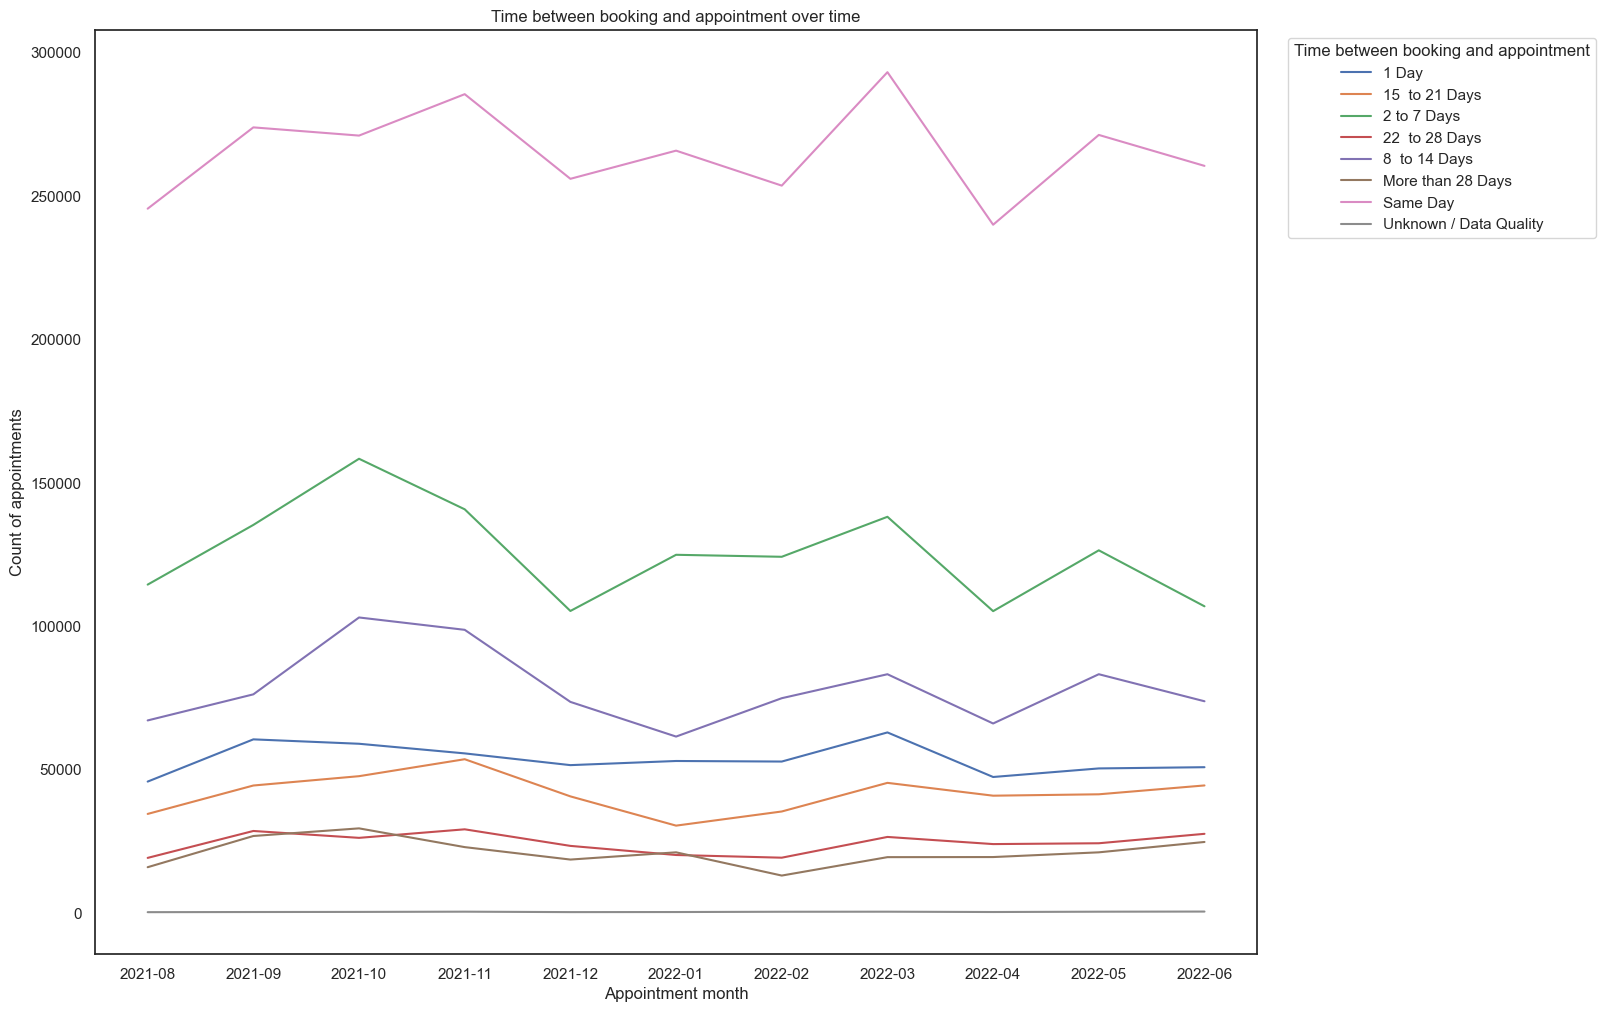

In [101]:
# Create a line plot to answer the question.
ax = sns.lineplot(data=ar_agg,
             x='appointment_month',
             y='count_of_appointments',
             hue='time_between_book_and_appointment',
             errorbar=None)

# Format the plot.
ax.set_title("Time between booking and appointment over time")
ax.set_xlabel("Appointment month")
ax.set_ylabel("Count of appointments")
ax.legend(title="Time between booking and appointment",
          bbox_to_anchor=(1.02,1),
          loc='upper left')
plt.savefig("time between booking and appointment.png")

**Question 5:** Are there any trends in time between booking and appointment?
The vast majority of appointments are same day. This is not because of the NHS being efficient, but rather the "8AM scramble" that has been spoken about in the media.

**Question 6:** How do the various service settings compare?

In [102]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [103]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_ss_month = nc.groupby(['service_setting','appointment_month'])\
    ['count_of_appointments'].sum().reset_index()
# View the DataFrame.
nc_ss_month.head()

,service_setting,appointment_month,count_of_appointments
0,Extended Access Provision,2021-08,160927
1,Extended Access Provision,2021-09,187906
2,Extended Access Provision,2021-10,209539
3,Extended Access Provision,2021-11,207577
4,Extended Access Provision,2021-12,173504


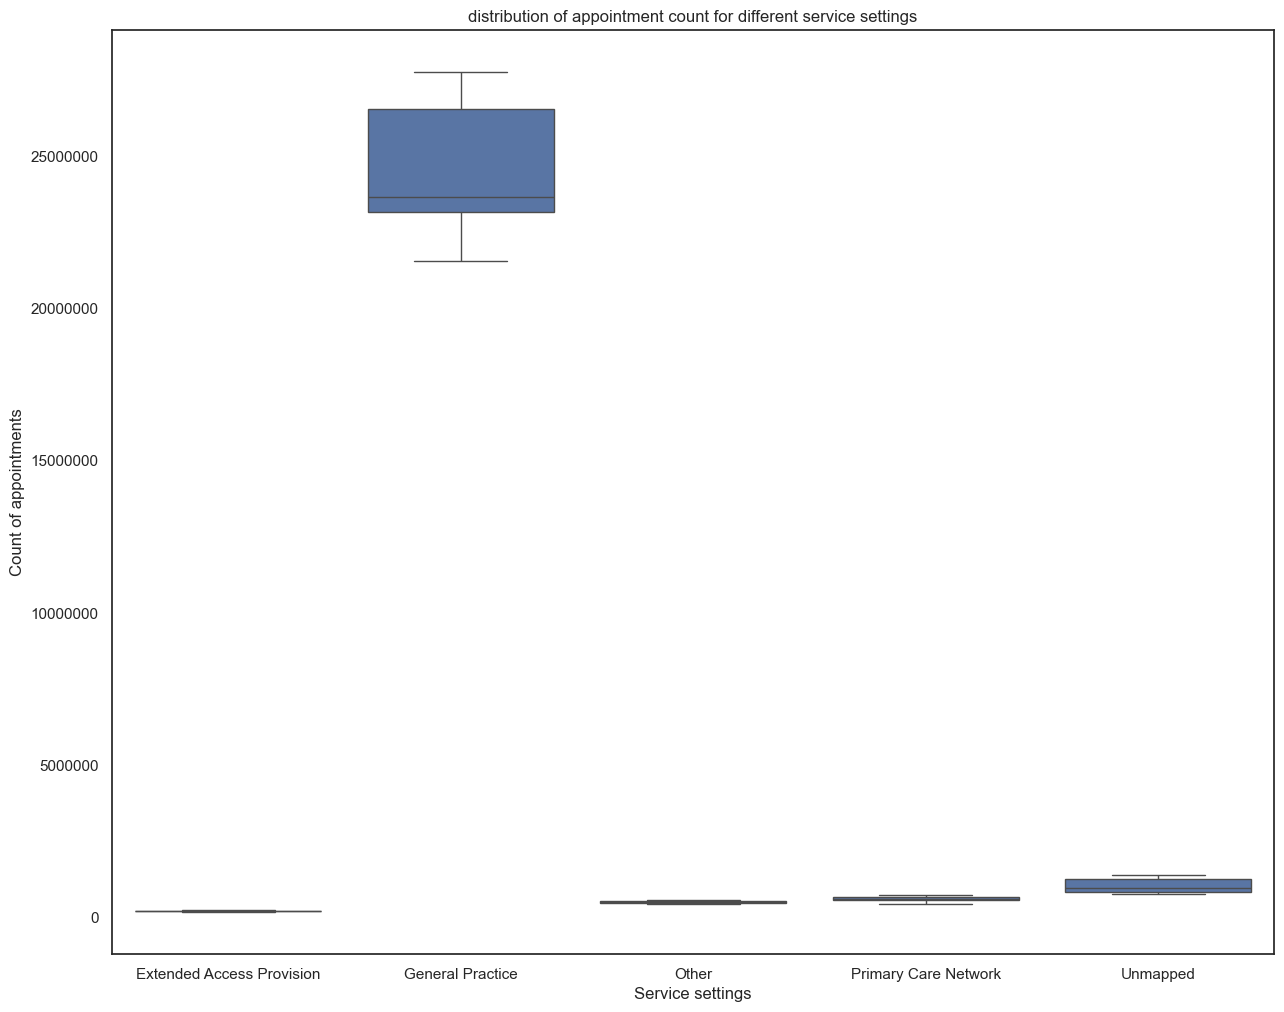

In [104]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
ax = sns.boxplot(data=nc_ss_month,
            x='service_setting',
            y='count_of_appointments')

# Format the plot
ax.set_title("distribution of appointment count for different service settings")
ax.set_xlabel("Service settings")
ax.set_ylabel("Count of appointments")
plt.ticklabel_format(style='plain', axis='y')
plt.savefig("service setting with GP boxplot.png")

The General practice box plot distorts the rest of the information for other service settings. It would be advisable to pl

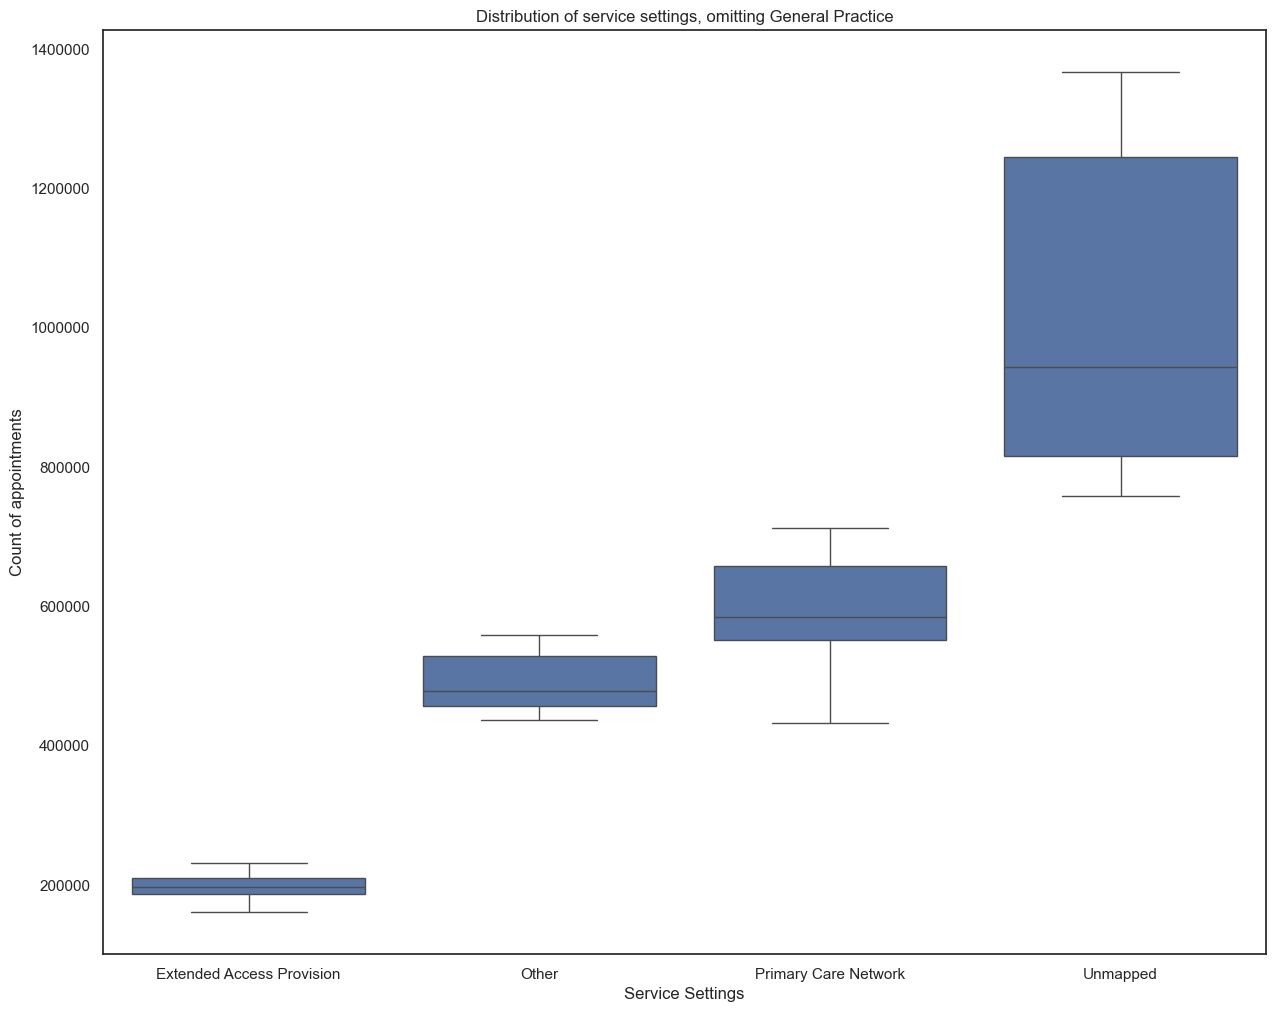

In [105]:
# Filter out GP.
nc_ss_month_filter = (nc_ss_month[nc_ss_month['service_setting'] != 'General Practice'])

# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
ax = sns.boxplot(data=nc_ss_month_filter,
            x='service_setting',
            y='count_of_appointments')

# Format the plot.
ax.set_title("Distribution of service settings, omitting General Practice")
ax.set_xlabel("Service Settings")
ax.set_ylabel("Count of appointments")
plt.ticklabel_format(style='plain', axis='y')
plt.savefig("boxplot without GP.png")

Unmapped has the biggest distribution of appointments. This shows another data entry error. Primary care network is the biggest after unmappep.

# Additional analysis

In [106]:
# View ar DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
3652,E54000034,2021-08,Attended,GP,Face-to-Face,1 Day,6553,2021-08-01
3653,E54000034,2021-08,Attended,GP,Face-to-Face,15 to 21 Days,2390,2021-08-01
3654,E54000034,2021-08,Attended,GP,Face-to-Face,2 to 7 Days,10547,2021-08-01
3655,E54000034,2021-08,Attended,GP,Face-to-Face,22 to 28 Days,937,2021-08-01
3656,E54000034,2021-08,Attended,GP,Face-to-Face,8 to 14 Days,4961,2021-08-01


In [107]:
# Group appointment status and appointment mode and time between with count of appointments.
ar_apptStatus = ar.groupby(['appointment_status','appointment_mode',
                            'time_between_book_and_appointment'])\
    ['count_of_appointments'].sum().reset_index()

# View new DataFrame,
ar_apptStatus.head()

,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,Attended,Face-to-Face,1 Day,14889127
1,Attended,Face-to-Face,15 to 21 Days,12093076
2,Attended,Face-to-Face,2 to 7 Days,37605539
3,Attended,Face-to-Face,22 to 28 Days,7104424
4,Attended,Face-to-Face,8 to 14 Days,23786237


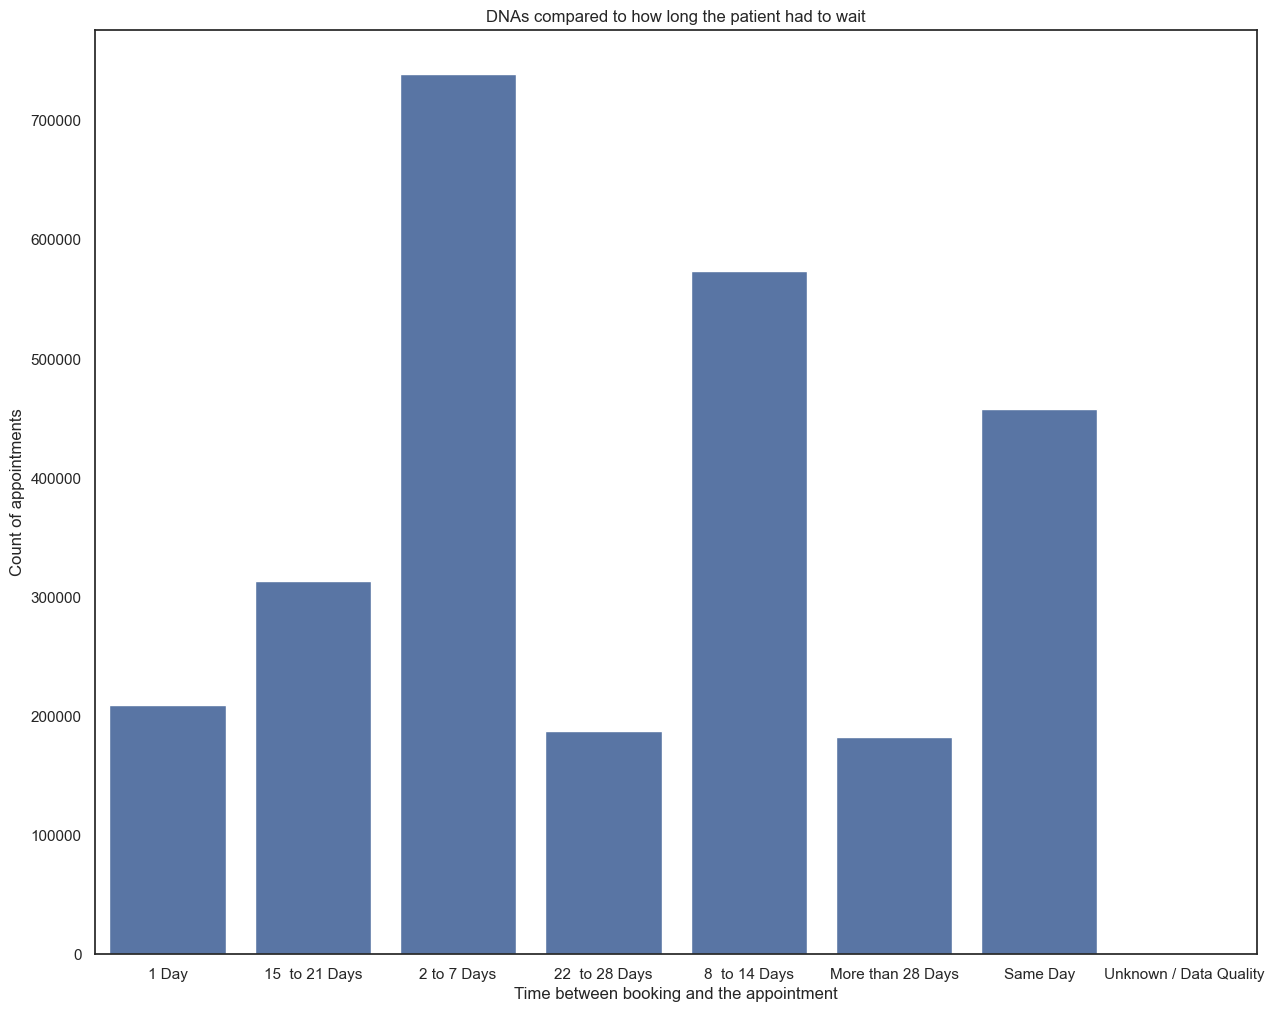

In [108]:
# Filter DataFrame further on DNA.
ar_apptStatus_filt = ar_apptStatus[ar_apptStatus['appointment_status'] == 'DNA']

# Create a barplot.
ax = sns.barplot(data=ar_apptStatus_filt,
                 x='time_between_book_and_appointment',
                 y='count_of_appointments',
                 errorbar=None)

# Format Plot
ax.set_title("DNAs compared to how long the patient had to wait")
ax.set_xlabel("Time between booking and the appointment")
ax.set_ylabel("Count of appointments")
plt.savefig("DNAs appointment time.png")

This shows that the most DNAs are when patients have to wait up to two weeks for an appointment. Surprisingly, same day appointments are being missed a lot as well. It would be interesting to see the different appointment modes compared to how many are missed.

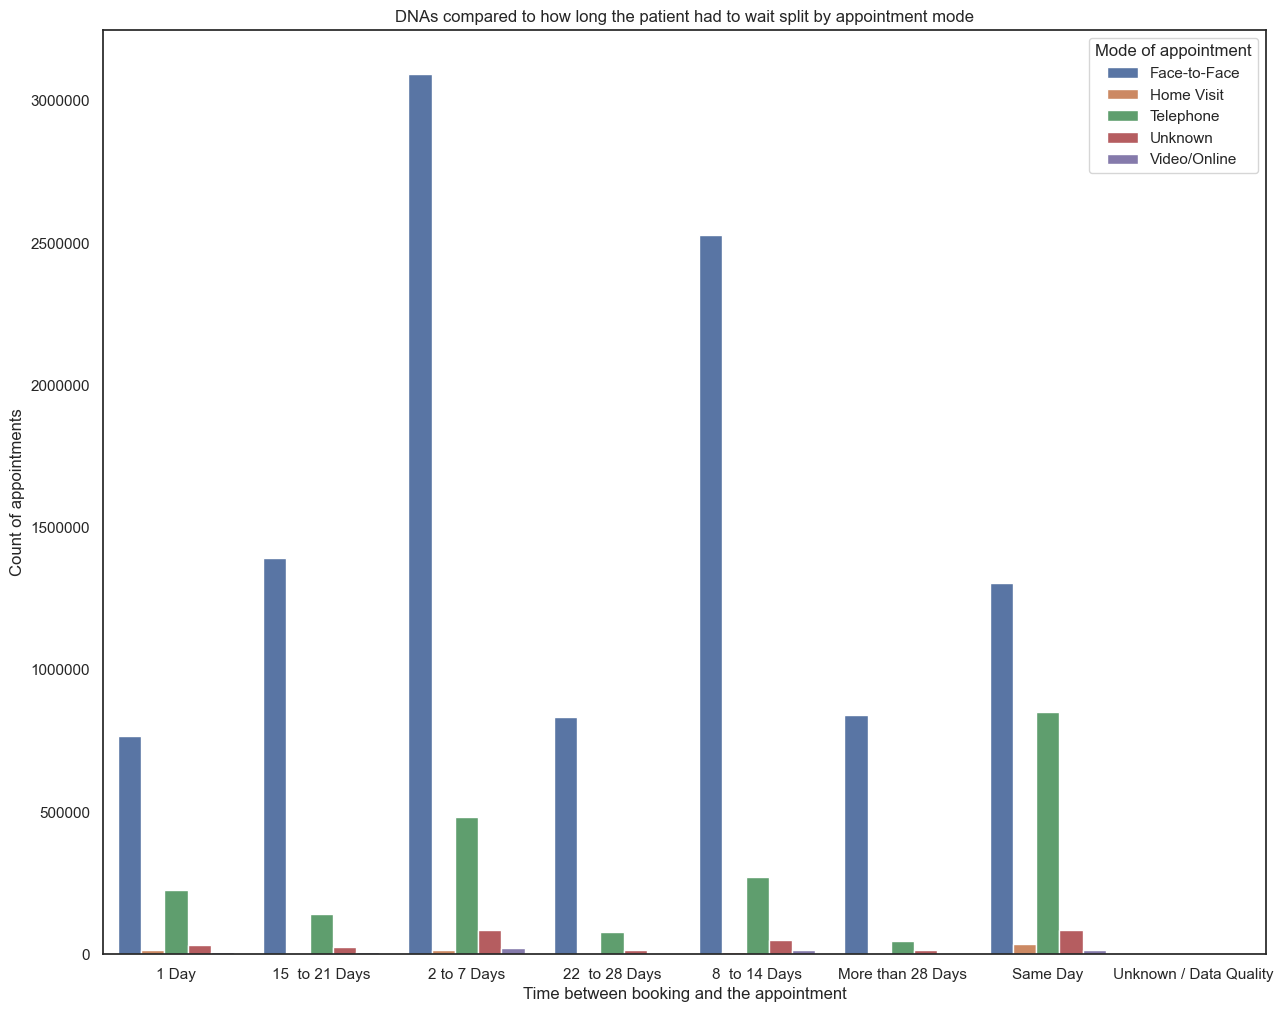

In [109]:
# Create a barplot to look at different appointment modes of missed appointments.
ax = sns.barplot(data=ar_apptStatus_filt,
                 x='time_between_book_and_appointment',
                 y='count_of_appointments',
                 hue='appointment_mode',
                 errorbar=None)

# Format the plot.
ax.set_title("DNAs compared to how long the patient had to wait split by appointment mode")
ax.set_xlabel("Time between booking and the appointment")
ax.set_ylabel("Count of appointments")
ax.legend(title="Mode of appointment")
plt.ticklabel_format(style='plain', axis='y')
plt.savefig("DNAs time appointment mode.png")


When we break down the number of appointments missed compared to the time the patient waited between booking the appointment by the appointment mode, we can see that most of the appointments are missed when they are face-to-face. However, the same day appointments have a higher telephone bar (green) relative to the rest of the time between booking categories. This suggests that the patient is given a window for a call which is missed - the window is advised within the metadata file.

### Provide a summary of your findings and recommendations based on the analysis.

> Double click to insert your summary.